# **Proyecto final: Proporcionar sugerencias basadas en datos para Recursos Humanos**


## Descripción y entregables

Este proyecto final es una oportunidad para que analices un conjunto de datos y construyas modelos predictivos que puedan proporcionar ideas al departamento de Recursos Humanos (RRHH) de una gran firma de consultoría.

Al completar, tendrás dos artefactos que podrás presentar a futuros empleadores. Uno es un resumen breve de una página de este proyecto que presentarás a las partes interesadas externas como el profesional de datos en Salifort Motors. El otro es un cuaderno de código completo proporcionado aquí. Basándote en tus cursos previos, selecciona un método para completar este proyecto: usa ya sea un modelo de regresión o un modelo de aprendizaje automático para predecir si un empleado dejará la empresa. El ejemplo que sigue a esta actividad muestra ambos enfoques, pero solo necesitas hacer uno.

En tus entregables, incluirás la evaluación del modelo (y la interpretación si es aplicable), una(s) visualización(es) de datos de tu elección que esté(n) directamente relacionada(s) con la pregunta que hagas, consideraciones éticas, y los recursos que utilizaste para solucionar problemas y encontrar respuestas o soluciones.


# **Etapas PACE**


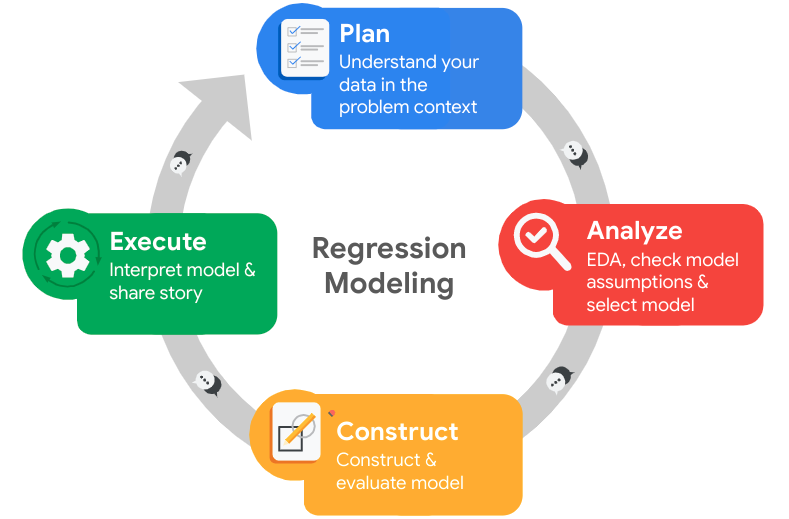

## **Ritmo: Plan**

Considere las preguntas en su Documento de Estrategia PACE para reflexionar sobre la etapa de Planificación.

En esta etapa, considere lo siguiente:


### Entender el escenario empresarial y el problema

El departamento de recursos humanos en Salifort Motors quiere tomar algunas iniciativas para mejorar los niveles de satisfacción de los empleados en la empresa. Ellos recopilaron datos de los empleados, pero ahora no saben qué hacer con ellos. Se refieren a ti como un profesional en análisis de datos y te piden que proporciones sugerencias basadas en datos. Ellos tienen la siguiente pregunta: ¿qué es probable que haga que el empleado deje la empresa?

Tus objetivos en este proyecto son analizar los datos recopilados por el departamento de recursos humanos y construir un modelo que prediga si un empleado dejará o no la empresa.

Si puedes predecir qué empleados tienen probabilidades de renunciar, podría ser posible identificar factores que contribuyen a su salida. Debido a que es un proceso que consume tiempo y es costoso encontrar, entrevistar y contratar nuevos empleados, aumentar la retención de empleados será beneficioso para la empresa.


### Familiarízate con el conjunto de datos de Recursos Humanos

El conjunto de datos que usarás en este laboratorio contiene 15,000 filas y 10 columnas para las variables listadas a continuación.

**Nota:** no necesitas descargar ningún dato para completar este laboratorio. Para más información sobre los datos, consulta su fuente en [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Descripción |
-----|-----|
satisfaction_level|Nivel de satisfacción laboral reportado por el empleado [0&ndash;1]|
last_evaluation|Puntuación de la última evaluación de desempeño del empleado [0&ndash;1]|
number_project|Número de proyectos en los que contribuye el empleado|
average_monthly_hours|Promedio de horas trabajadas por el empleado al mes|
time_spend_company|Cuánto tiempo ha estado el empleado en la empresa (años)
Work_accident|Si el empleado experimentó o no un accidente en el trabajo
left|Si el empleado dejó o no la empresa
promotion_last_5years|Si el empleado fue promovido en los últimos 5 años
Department|El departamento del empleado
salary|El salario del empleado (dólares estadounidenses)


### Reflexiona sobre estas preguntas mientras completas la etapa de planificación.

* ¿Quiénes son tus partes interesadas para este proyecto?
- ¿Qué estás tratando de resolver o lograr?
- ¿Cuáles son tus observaciones iniciales cuando exploras los datos?
- ¿Qué recursos encuentras que estás usando mientras completas esta etapa? (Asegúrate de incluir los enlaces.)
- ¿Tienes alguna consideración ética en esta etapa?


[Doble clic para ingresar sus respuestas aquí.]


## Paso 1. Importaciones

*   Importar paquetes
*   Cargar conjunto de datos


### Importar paquetes


In [136]:
# Import packages
### YOUR CODE HERE ### 
# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle
import platform


print("Entorno de ejecución")
print("=" * 30)
print(f"Python       : {platform.python_version()}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {__import__("sklearn").__version__}")
print(f"XGBoost      : {__import__("xgboost").__version__}")
print("=" * 30)


Entorno de ejecución
Python       : 3.13.7
NumPy        : 2.4.2
Pandas       : 3.0.0
Scikit-learn : 1.9.0
XGBoost      : 3.4.0


### Cargar conjunto de datos

`Pandas` se usa para leer un conjunto de datos llamado **`HR_capstone_dataset.csv`.**  Como se muestra en esta celda, el conjunto de datos ha sido cargado automáticamente para ti. No necesitas descargar el archivo .csv, ni proporcionar más código, para acceder al conjunto de datos y continuar con este laboratorio. Por favor, continúa con esta actividad completando las siguientes instrucciones.


In [137]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
### YOUR CODE HERE ###
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Paso 2. Exploración de datos (EDA inicial y limpieza de datos)

- Entender tus variables
- Limpiar tu conjunto de datos (datos faltantes, datos redundantes, valores atípicos)


### Recopilar información básica sobre los datos


In [138]:
# Gather basic information about the data
### YOUR CODE HERE ###
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Recolectar estadísticas descriptivas sobre los datos


In [139]:
# Gather descriptive statistics about the data
### YOUR CODE HERE ###
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Renombrar columnas


Como paso de limpieza de datos, cambie el nombre de las columnas según sea necesario. Estandarice los nombres de las columnas para que todos estén en `snake_case`, corrija cualquier nombre de columna mal escrito y haga que los nombres de las columnas sean más concisos según sea necesario.


In [140]:
# Display all column names
### YOUR CODE HERE ###
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [141]:
# Rename columns as needed
### YOUR CODE HERE ###
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})


# Display all column names after the update
### YOUR CODE HERE ###
df0.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='str')

### Verificar valores faltantes


Verificar si hay valores faltantes en los datos.


In [142]:
# Check for missing values
### YOUR CODE HERE ###
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Verificar duplicados


Check for any duplicate entries in the data.


In [143]:
# Check for duplicates
### YOUR CODE HERE ###
df0.duplicated().sum()

np.int64(3008)

In [144]:
# Inspect some rows containing duplicates as needed
### YOUR CODE HERE ###
df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


In [145]:
# Drop duplicates and save resulting dataframe in a new variable as needed
### YOUR CODE HERE ###
df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
### YOUR CODE HERE ###
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Revisar valores atípicos


Verificar si hay valores atípicos en los datos.


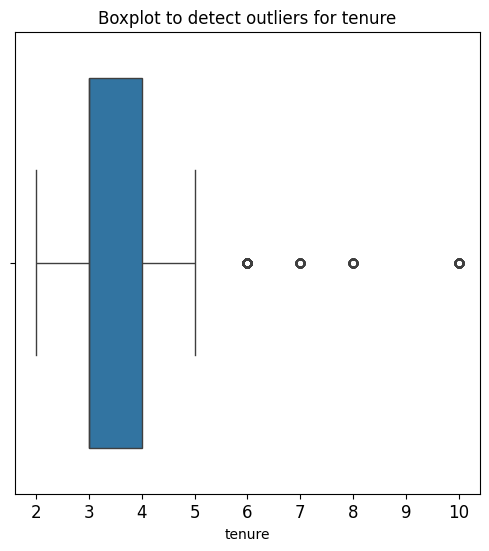

In [146]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
### YOUR CODE HERE ###
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()


In [147]:
# Determine the number of rows containing outliers
### YOUR CODE HERE ###
percentile25 = df1['tenure'].quantile(0.25)
percentile75 = df1['tenure'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

print("=" * 60)
print("ANÁLISIS DE OUTLIERS - MÉTODO IQR (RANGO INTERCUARTIL)")
print("=" * 60)
print(f"\n📊 Variable analizada: 'tenure' (años en la empresa)")
print(f"\n📈 Estadísticas calculadas:")
print(f"   • Percentil 25 (Q1): {percentile25:.2f} años")
print(f"   • Percentil 75 (Q3): {percentile75:.2f} años")
print(f"   • Rango Intercuartil (IQR): {iqr:.2f} años")
print(f"\n⚠️  Límites para detectar outliers:")
print(f"   • Límite inferior: {lower_limit:.2f} años")
print(f"   • Límite superior: {upper_limit:.2f} años")
print(f"\n🔍 Resultados:")
print(f"   • Total de filas con outliers: {len(outliers)}")
print(f"   • Porcentaje del dataset: {(len(outliers)/len(df1)*100):.2f}%")
print(f"\n💡 Interpretación:")
print(f"   Los valores fuera del rango [{lower_limit:.2f}, {upper_limit:.2f}]")
print(f"   se consideran outliers y pueden afectar el modelo.")
print("=" * 60)

ANÁLISIS DE OUTLIERS - MÉTODO IQR (RANGO INTERCUARTIL)

📊 Variable analizada: 'tenure' (años en la empresa)

📈 Estadísticas calculadas:
   • Percentil 25 (Q1): 3.00 años
   • Percentil 75 (Q3): 4.00 años
   • Rango Intercuartil (IQR): 1.00 años

⚠️  Límites para detectar outliers:
   • Límite inferior: 1.50 años
   • Límite superior: 5.50 años

🔍 Resultados:
   • Total de filas con outliers: 824
   • Porcentaje del dataset: 6.87%

💡 Interpretación:
   Los valores fuera del rango [1.50, 5.50]
   se consideran outliers y pueden afectar el modelo.


Ciertos tipos de modelos son más sensibles a los valores atípicos que otros. Cuando llegues a la etapa de construir tu modelo, considera si eliminar los valores atípicos, en función del tipo de modelo que decidas usar.


# pAce: Etapa de Análisis
- Realizar EDA (analizar relaciones entre variables)


### Reflexiona sobre estas preguntas mientras completas la etapa de análisis.

- ¿Qué observaste acerca de las relaciones entre variables?
- ¿Qué observas acerca de las distribuciones en los datos?
- ¿Qué transformaciones hiciste con tus datos? ¿Por qué elegiste tomar esas decisiones?
- ¿Cuáles son algunos propósitos del Análisis Exploratorio de Datos (EDA) antes de construir un modelo predictivo?
- ¿Qué recursos encuentras que estás usando mientras completas esta etapa? (Asegúrate de incluir los enlaces.)
- ¿Tienes alguna consideración ética en esta etapa?


[Haz doble clic para ingresar tus respuestas aquí.]


## Paso 2. Exploración de Datos (Continuar EDA)

Comience por entender cuántos empleados se fueron y qué porcentaje de todos los empleados representa esta cifra.


In [148]:
# Get numbers of people who left vs. stayed
### YOUR CODE HERE ###
print(df1['left'].value_counts())
print()

# Get percentages of people who left vs. stayed
### YOUR CODE HERE ###
print(df1['left'].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


### Visualizaciones de datos


Ahora, examina las variables que te interesan, y crea gráficos para visualizar las relaciones entre variables en los datos.


### Distribuciones de las variables continuas

Aquí exploramos de forma univariada la distribución de cada variable numérica.
Esto nos ayuda a entender la forma de los datos (simetría, concentración, valores
extremos) antes de modelar.

Observamos en una mirada rápida:
- `satisfaction_level` y `last_evaluation` tienen varios "picos" (modas), señal
  de que existe una mezcla de perfiles de empleados.
- `average_monthly_hours` se concentra alrededor de 200 h/mes, pero con una cola
  larga hacia más de 250 h (empleados sobrecargados).
- En `number_project` casi nadie tiene 7 proyectos, y ese grupo está altamente
  relacionado con la rotación.
- La variable objetivo `left` está desbalanceada (≈83% se queda / 17% se va).


1. DISTRIBUCIONES DE VARIABLES CONTINUAS


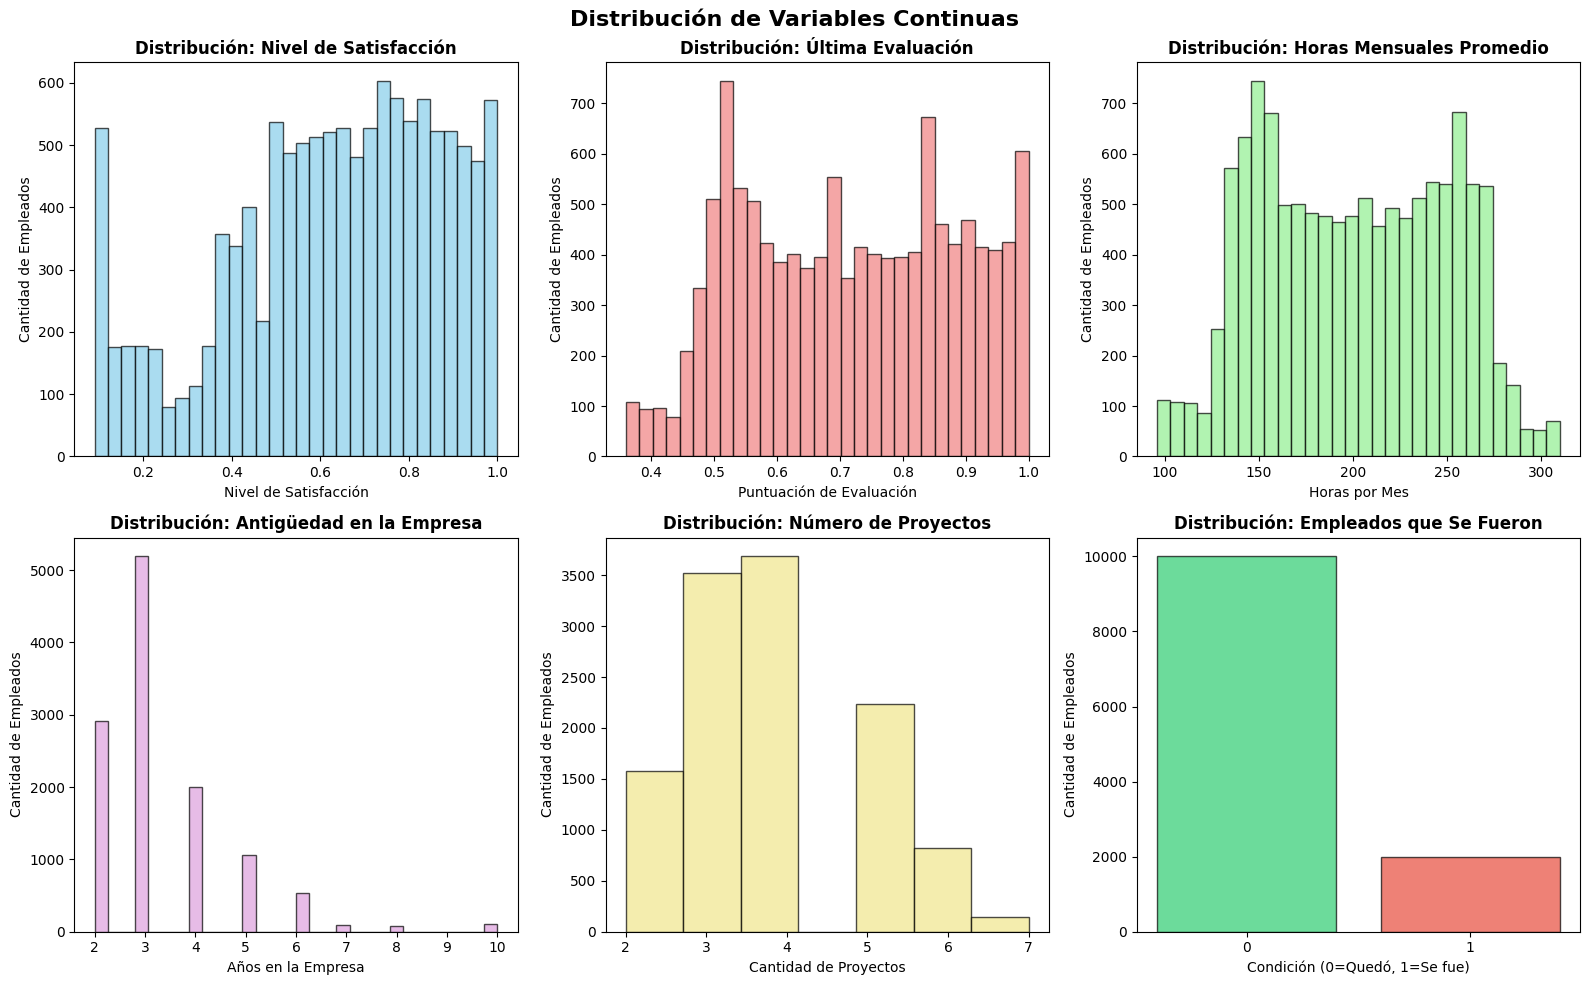

In [149]:
# ============================================================================
# SECCIÓN: VISUALIZACIONES DE DATOS - EDA COMPLETO
# ============================================================================

# ANÁLISIS UNIVARIADO: DISTRIBUCIONES DE VARIABLES CONTINUAS
# ============================================================================
print("\n" + "="*70)
print("1. DISTRIBUCIONES DE VARIABLES CONTINUAS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribución de Variables Continuas', fontsize=16, fontweight='bold')

# Satisfacción laboral
axes[0, 0].hist(df1['satisfaction_level'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución: Nivel de Satisfacción', fontweight='bold')
axes[0, 0].set_xlabel('Nivel de Satisfacción')
axes[0, 0].set_ylabel('Cantidad de Empleados')

# Última evaluación
axes[0, 1].hist(df1['last_evaluation'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución: Última Evaluación', fontweight='bold')
axes[0, 1].set_xlabel('Puntuación de Evaluación')
axes[0, 1].set_ylabel('Cantidad de Empleados')

# Horas mensuales promedio
axes[0, 2].hist(df1['average_monthly_hours'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Distribución: Horas Mensuales Promedio', fontweight='bold')
axes[0, 2].set_xlabel('Horas por Mes')
axes[0, 2].set_ylabel('Cantidad de Empleados')

# Antigüedad
axes[1, 0].hist(df1['tenure'], bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución: Antigüedad en la Empresa', fontweight='bold')
axes[1, 0].set_xlabel('Años en la Empresa')
axes[1, 0].set_ylabel('Cantidad de Empleados')

# Número de proyectos
axes[1, 1].hist(df1['number_project'], bins=7, color='khaki', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución: Número de Proyectos', fontweight='bold')
axes[1, 1].set_xlabel('Cantidad de Proyectos')
axes[1, 1].set_ylabel('Cantidad de Empleados')

# Variable objetivo (left)
left_counts = df1['left'].value_counts()
colors_left = ['#2ecc71', '#e74c3c']  # Verde para quedaron, rojo para se fueron
axes[1, 2].bar(left_counts.index, left_counts.values, color=colors_left, edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Distribución: Empleados que Se Fueron', fontweight='bold')
axes[1, 2].set_xlabel('Condición (0=Quedó, 1=Se fue)')
axes[1, 2].set_ylabel('Cantidad de Empleados')
axes[1, 2].set_xticks([0, 1])

plt.tight_layout()
plt.show()


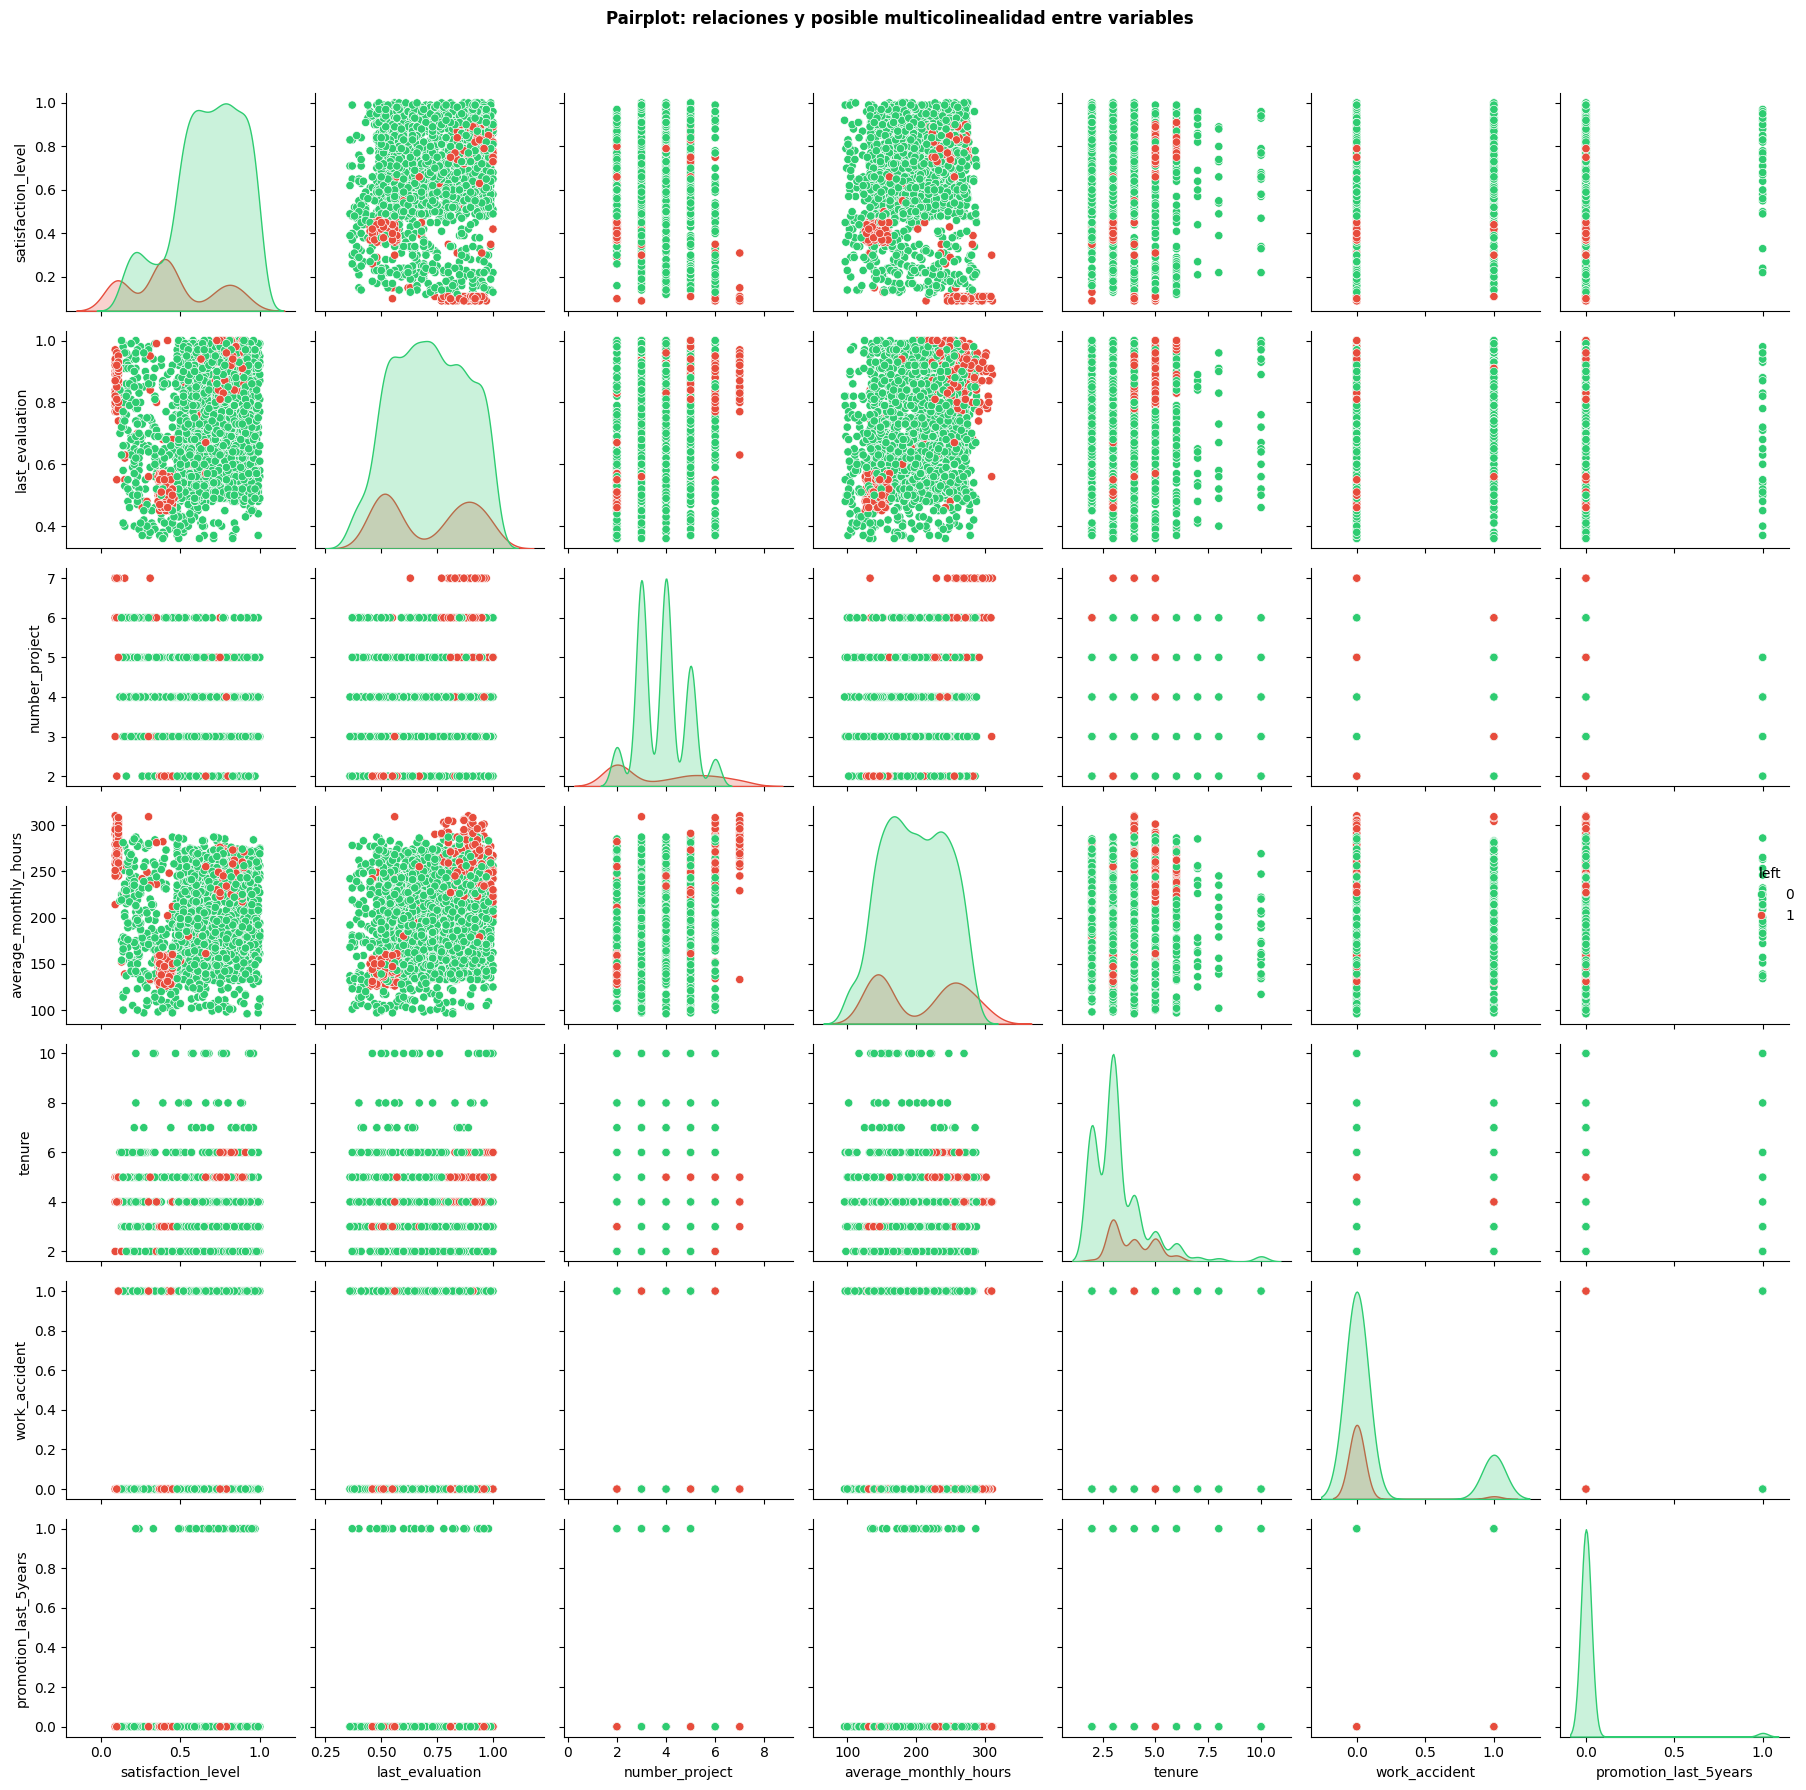

In [150]:
# Seleccionar variables numéricas de interés
pairplot_vars = ['satisfaction_level', 'last_evaluation', 'number_project',
                 'average_monthly_hours', 'tenure', 'work_accident',
                 'promotion_last_5years', 'left']

# Muestra para que el pairplot sea legible y rápido
pairplot_df = df1[pairplot_vars].sample(n=2000, random_state=42)

# Pairplot segmentado por rotación
g = sns.pairplot(pairplot_df, hue='left',
                 palette=['#2ecc71', '#e74c3c'],
                 diag_kind='kde')
g.fig.suptitle('Pairplot: relaciones y posible multicolinealidad entre variables',
               fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> Nota sobre por qué sirve para multicolinealidad (para comentar en clase):

- El pairplot muestra la relación entre pares de variables. Si dos variables se ven claramente asociadas (p.ej. last_evaluation y average_monthly_hours), pueden estar correlacionadas.
- Eso importa porque la regresión logística asume que no hay multicolinealidad severa. Si dos features están muy correlacionadas, los coeficientes se vuelven inestables.

### Horas trabajadas por número de proyectos

Este análisis combina dos variables que suelen estar relacionadas con la rotación.

En el boxplot se ve cómo las horas mensuales crecen con la cantidad de proyectos.
Y en el histograma observamos dos hallazgos importantes:

1. Hay **dos grupos** que se van:
   - (A) quienes trabajaron **menos horas** que sus pares con el mismo número de
     proyectos (posiblemente despedidos, o en proceso de salida).
   - (B) quienes trabajaron **mucho más** (probablemente renunciaron por burnout).
2. **Todos** los empleados con 7 proyectos se fueron. La carga de trabajo parece
   ser el principal disparador de la rotación.

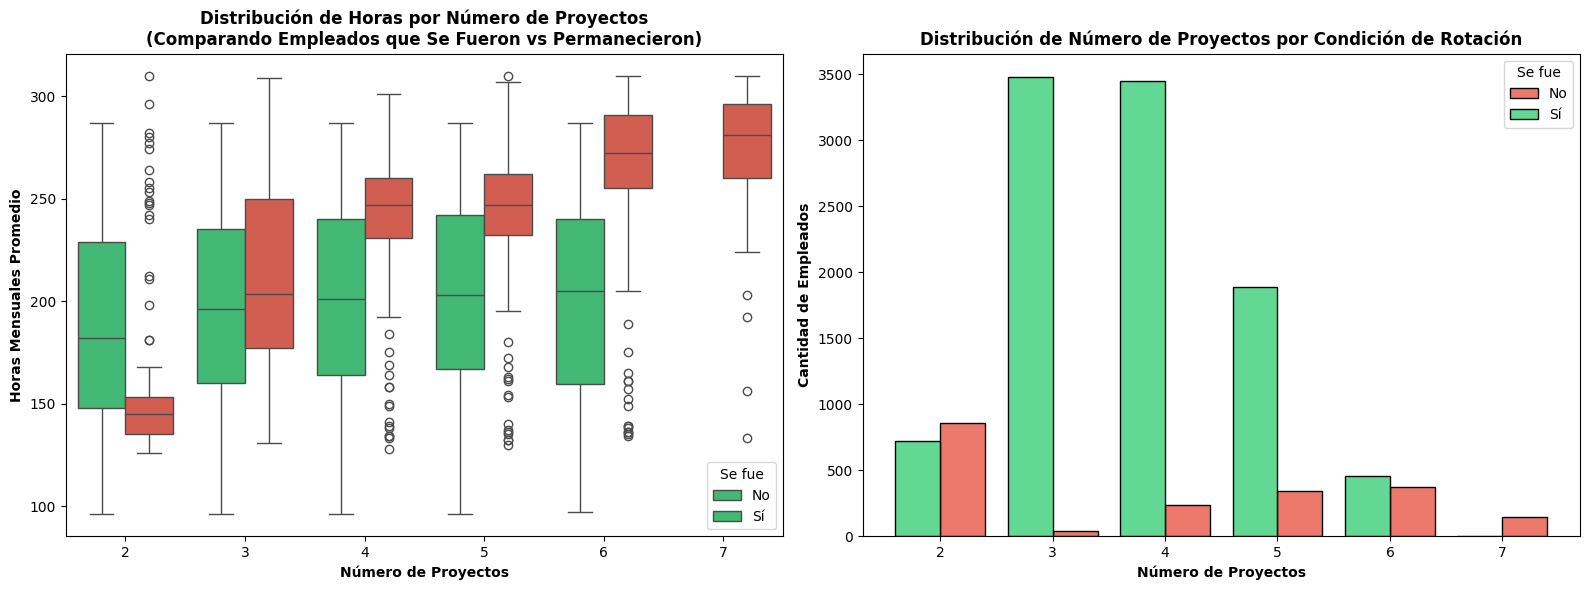

In [151]:
# ANÁLISIS BIVARIADO: SATISFACCIÓN vs HORAS vs PROYECTOS

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: Horas mensuales por número de proyectos (comparando left)
sns.boxplot(data=df1, x='number_project', y='average_monthly_hours', hue='left', 
            palette=['#2ecc71', '#e74c3c'], ax=ax[0])
ax[0].set_title('Distribución de Horas por Número de Proyectos\n(Comparando Empleados que Se Fueron vs Permanecieron)', 
                fontweight='bold', fontsize=12)
ax[0].set_xlabel('Número de Proyectos', fontweight='bold')
ax[0].set_ylabel('Horas Mensuales Promedio', fontweight='bold')
ax[0].legend(title='Se fue', labels=['No', 'Sí'])

# Histograma: Distribución de proyectos segmentada por left
sns.histplot(data=df1, x='number_project', hue='left', discrete=True, multiple='dodge',
             palette=['#2ecc71', '#e74c3c'], ax=ax[1], shrink=0.8)
ax[1].set_title('Distribución de Número de Proyectos por Condición de Rotación',
                fontweight='bold', fontsize=12)
ax[1].set_xlabel('Número de Proyectos', fontweight='bold')
ax[1].set_ylabel('Cantidad de Empleados', fontweight='bold')
ax[1].legend(title='Se fue', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()


In [152]:
# Confirmar que todos los que tienen 7 proyectos se fueron
df1[df1['number_project'] == 7]['left'].value_counts(normalize=1)

left
1    1.0
Name: proportion, dtype: float64

### Satisfacción laboral vs horas trabajadas

Este scatterplot cruza dos variables clave con la rotación.

Interpretación:
- El grupo que se fue (rojo) aparece en dos zonas:
  - trabajando **muchísimas horas** (240–315 h/mes) y con satisfacción muy baja
    (cercana a 0). Son empleados quemados (burnout).
  - con horas "normales" pero satisfacción media-baja (~0.4). Posible presión
    para trabajar más que otros compañeros.
- Hay un grupo que las **pasó bien**: 210–280 h/mes y satisfacción 0.7–0.9, y
  que mayormente permaneció.
- La línea punteada marca 166.67 h/mes (≈40 h/semana, 50 semanas/año): casi todos
  los empleados trabajan bastante más que el estándar.

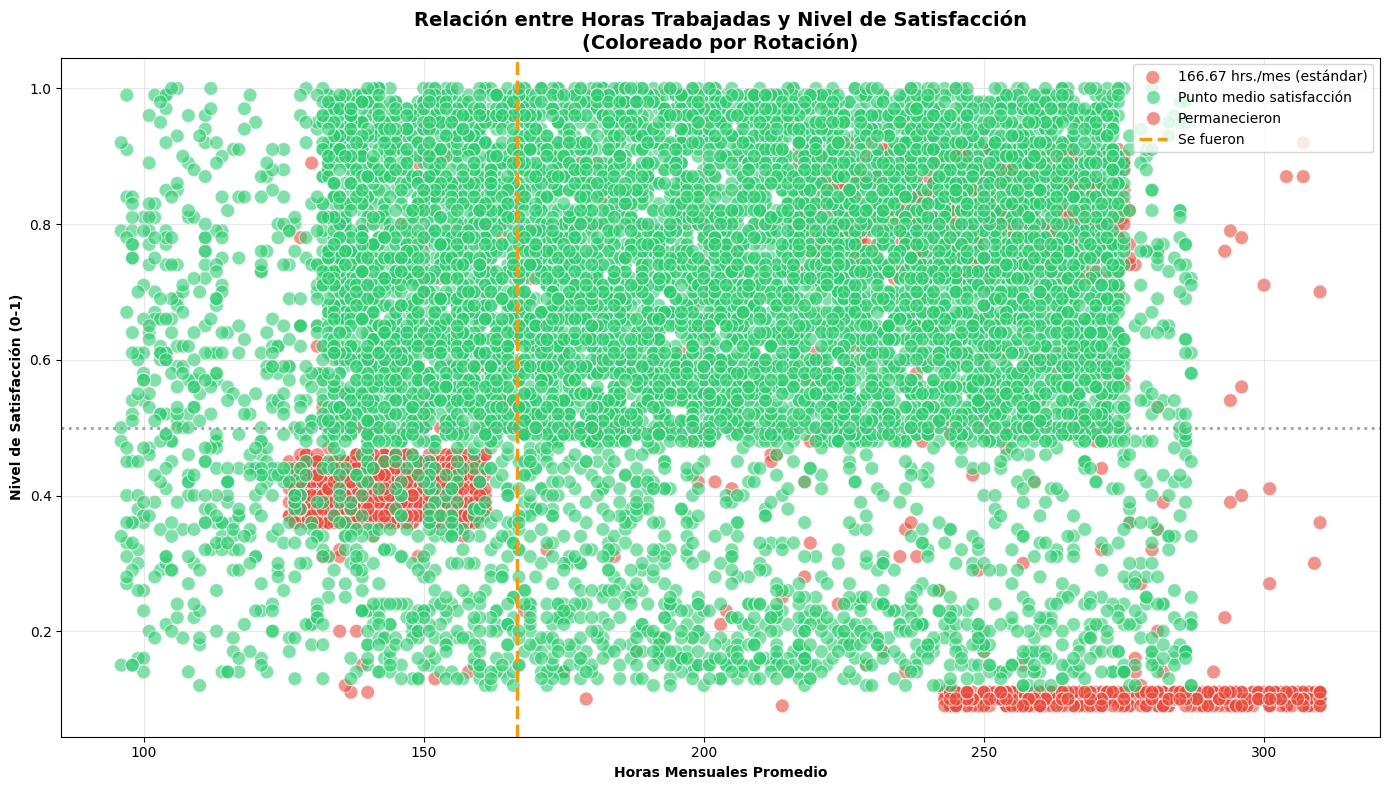

In [153]:

# SATISFACCIÓN vs HORAS TRABAJADAS
# ============================================================================

plt.figure(figsize=(14, 8))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', 
                hue='left', palette=['#2ecc71', '#e74c3c'], s=100, alpha=0.6)
plt.axvline(x=166.67, color='#f39c12', linestyle='--', linewidth=2.5, label='166.67 hrs./mes (estándar)')
plt.axhline(y=0.5, color='#95a5a6', linestyle=':', linewidth=2, label='Punto medio satisfacción')
plt.title('Relación entre Horas Trabajadas y Nivel de Satisfacción\n(Coloreado por Rotación)', 
          fontweight='bold', fontsize=14)
plt.xlabel('Horas Mensuales Promedio', fontweight='bold')
plt.ylabel('Nivel de Satisfacción (0-1)', fontweight='bold')
plt.legend(['166.67 hrs./mes (estándar)', 'Punto medio satisfacción', 'Permanecieron', 'Se fueron'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


> Insight clave: Hay dos grupos de empleados que se fueron:

- Grupo A: Trabajaban POCAS horas (posiblemente despedidos)
- Grupo B: Trabajaban MUCHAS horas (probablemente renunciaron)

### Antigüedad en la empresa vs nivel de satisfacción

Aquí miramos la satisfacción según cuántos años lleva el empleado.

Observaciones:
- Los empleados que se fueron (rojo) caen en dos categorías:
  - **Insatisfechos** con poca antigüedad.
  - **Muy satisfechos** con antigüedad media.
- Destaca que los empleados de **4 años** que se fueron tienen una satisfacción
  inusualmente baja. Vale la pena investigar si hubo cambios de política que
  afectaron a ese grupo.
- Los empleados con **mayor antigüedad** (más de 6 años) prácticamente no se van
  y su satisfacción está alineada con la de los que permanecen.
- El histograma muestra que hay **pocos** empleados con mucha antigüedad:
  probablemente los de mayor rango y mejor pagados.

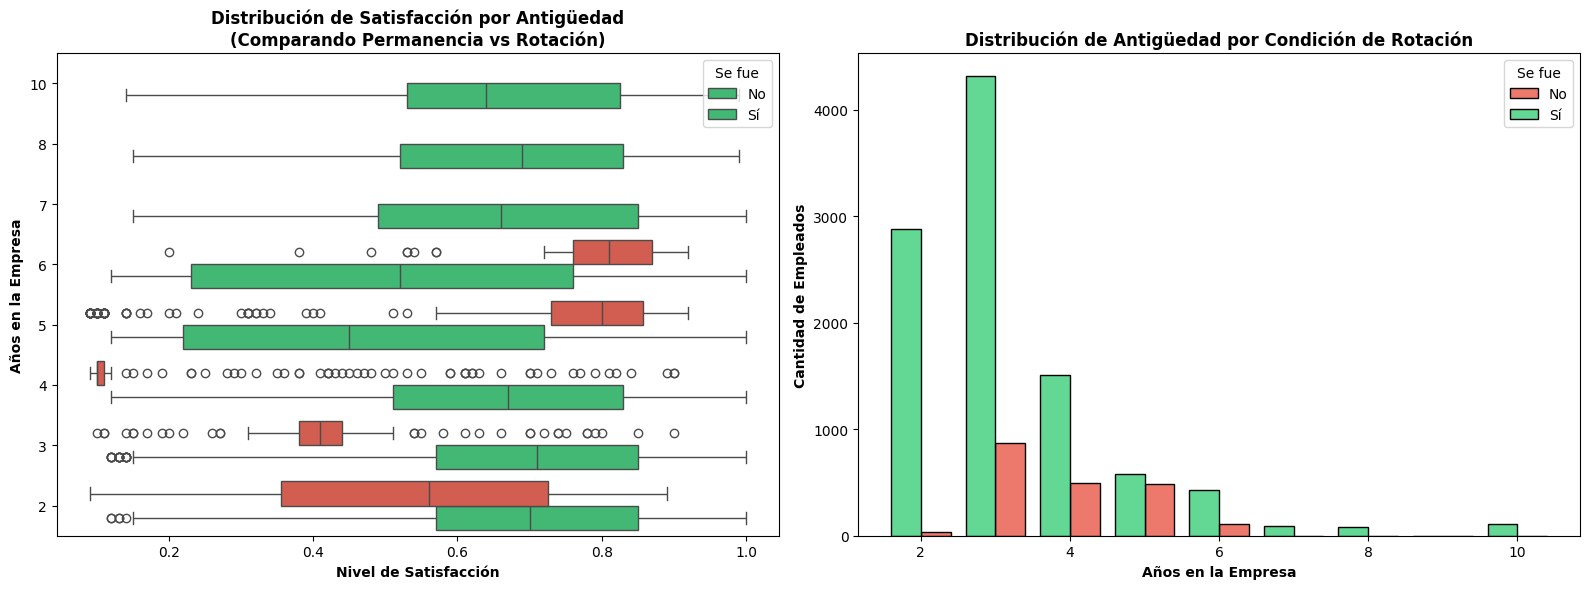

In [154]:
# ANTIGÜEDAD vs SATISFACCIÓN vs ROTACIÓN
# ============================================================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot: Satisfacción por antigüedad
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left',
            palette=['#2ecc71', '#e74c3c'], ax=ax[0], orient='h')
ax[0].invert_yaxis()
ax[0].set_title('Distribución de Satisfacción por Antigüedad\n(Comparando Permanencia vs Rotación)',
                fontweight='bold', fontsize=12)
ax[0].set_xlabel('Nivel de Satisfacción', fontweight='bold')
ax[0].set_ylabel('Años en la Empresa', fontweight='bold')
ax[0].legend(title='Se fue', labels=['No', 'Sí'])

# Histograma: Distribución de antigüedad
sns.histplot(data=df1, x='tenure', hue='left', discrete=True, multiple='dodge',
             palette=['#2ecc71', '#e74c3c'], ax=ax[1], shrink=0.8)
ax[1].set_title('Distribución de Antigüedad por Condición de Rotación',
                fontweight='bold', fontsize=12)
ax[1].set_xlabel('Años en la Empresa', fontweight='bold')
ax[1].set_ylabel('Cantidad de Empleados', fontweight='bold')
ax[1].legend(title='Se fue', labels=['No', 'Sí'])

plt.tight_layout()
plt.show()


In [155]:
print("\n📊 Estadísticas de satisfacción por grupo:")
df1.groupby('left')['satisfaction_level'].agg([np.mean, np.median]).round(3)


📊 Estadísticas de satisfacción por grupo:


,mean,median
left,,
0,0.667,0.69
1,0.440,0.41


### Última evaluación vs horas trabajadas

Cruzamos el desempeño (evaluación) con la carga horaria.

Observaciones:
- Hay una **correlación positiva** entre horas y puntuación: quien más trabaja,
  tiende a ser mejor evaluado.
- Pero aparecen dos grupos de quienes se fueron (rojo):
  - **sobrecargados y bien evaluados** (muchas horas, evaluación alta) → burnout.
  - **menos horas y evaluación más baja** → posible desvinculación.
- Poco comunes los empleados en el cuadrante superior izquierdo (muchas horas,
  evaluación baja): trabajar mucho casi siempre "rinde" en la evaluación, lo que
  empuja una cultura de sobreesfuerzo.
- La mayoría trabaja muy por encima de 166.67 h/mes.

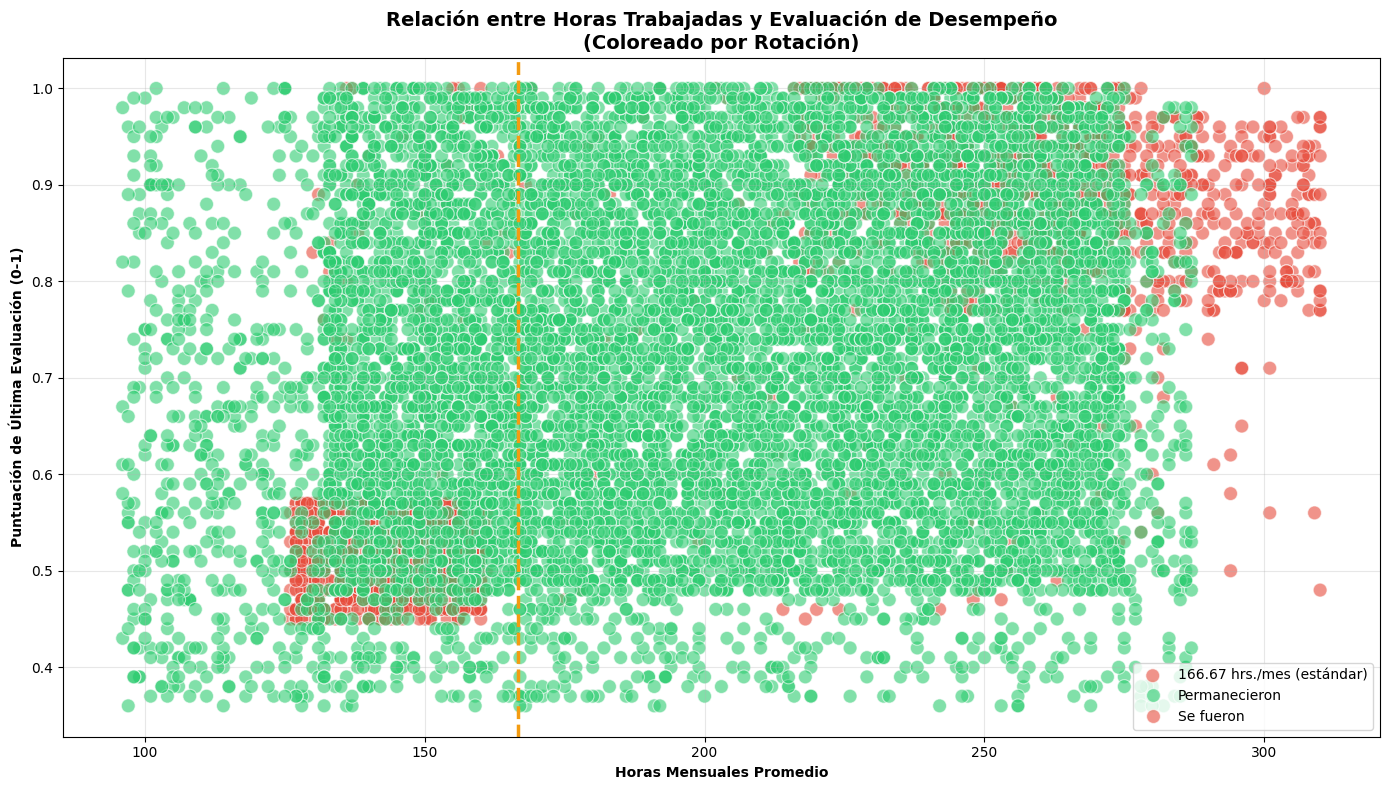

In [156]:

# EVALUACIÓN ÚLTIMA vs HORAS TRABAJADAS
# ============================================================================


plt.figure(figsize=(14, 8))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation',
                hue='left', palette=['#2ecc71', '#e74c3c'], s=100, alpha=0.6)
plt.axvline(x=166.67, color='#f39c12', linestyle='--', linewidth=2.5, label='166.67 hrs./mes (estándar)')
plt.title('Relación entre Horas Trabajadas y Evaluación de Desempeño\n(Coloreado por Rotación)',
          fontweight='bold', fontsize=14)
plt.xlabel('Horas Mensuales Promedio', fontweight='bold')
plt.ylabel('Puntuación de Última Evaluación (0-1)', fontweight='bold')
plt.legend(['166.67 hrs./mes (estándar)', 'Permanecieron', 'Se fueron'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Matriz de correlación

Revisamos la correlación lineal entre las variables numéricas. Nos interesa
especialmente la relación con la variable objetivo `left`, y también detectar
posible **multicolinealidad** entre las features (relevante para la regresión
logística).

Hallazgos clave:
- La correlación más fuerte con `left` es **negativa** con `satisfaction_level`
  (-0.35): a menor satisfacción, mayor rotación. Es la variable individualmente
  más informativa.
- `tenure`, `average_monthly_hours` y `number_project` tienen correlación
  positiva (aunque débil) con `left`.
- `work_accident` y `promotion_last_5years` correlacionan **negativo**: quienes
  sufrieron accidentes o fueron promovidos tienden a quedarse.
- Para multicolinealidad: `last_evaluation`, `average_monthly_hours` y
  `number_project` se correlacionan positivamente entre sí (todo lo que está
  asociado a "trabajar mucho"). No es una colinealidad severa, pero vale
  tenerla presente.

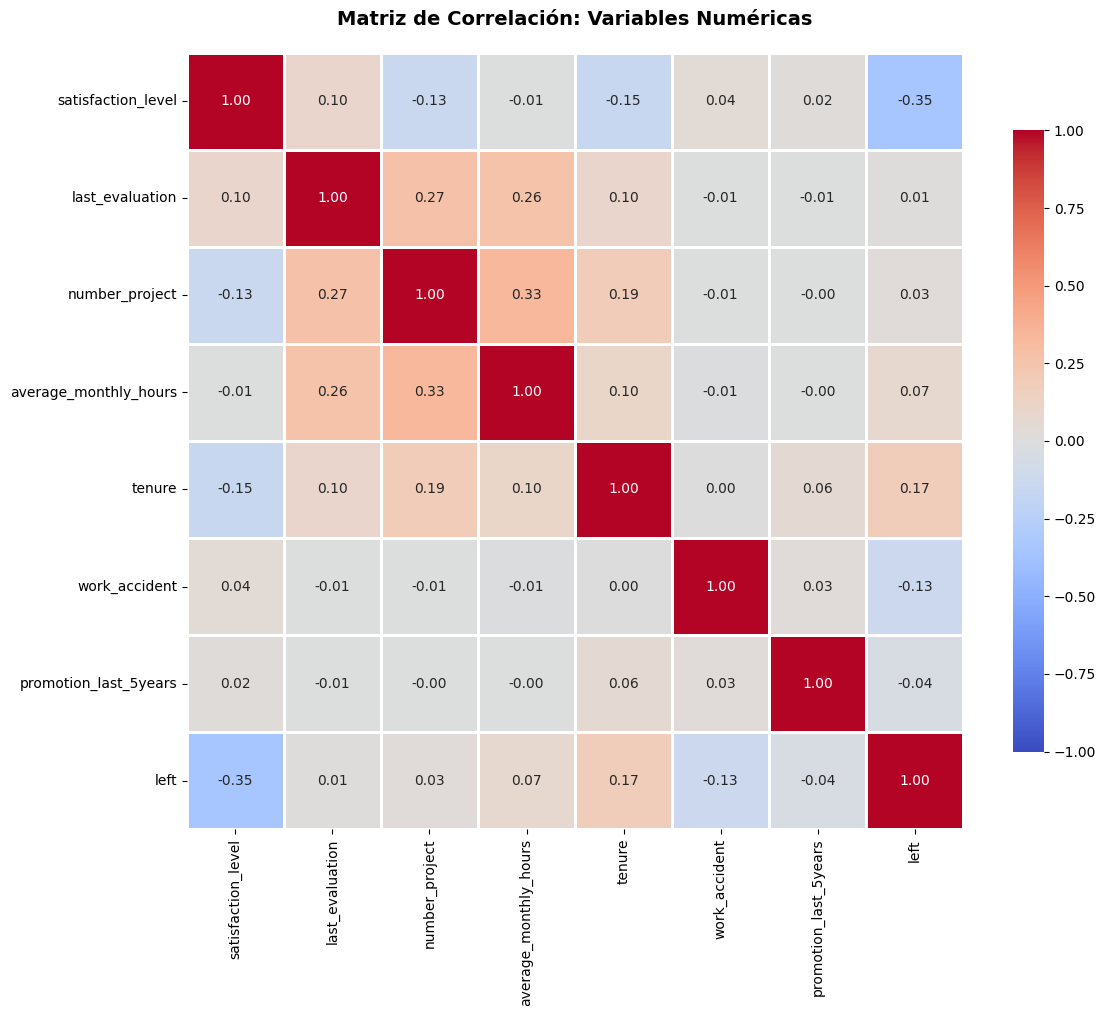


🔍 Correlaciones más fuertes con 'left' (rotación):
left                     1.000000
tenure                   0.173295
average_monthly_hours    0.070409
number_project           0.030928
last_evaluation          0.013520
promotion_last_5years   -0.044657
work_accident           -0.125436
satisfaction_level      -0.350558
Name: left, dtype: float64


In [157]:
# MATRIZ DE CORRELACIÓN Y HEATMAP
# ============================================================================

# Seleccionar variables numéricas
numeric_cols = ['satisfaction_level', 
                'last_evaluation', 
                'number_project',
                'average_monthly_hours', 
                'tenure', 
                'work_accident', 
                'promotion_last_5years', 
                'left']

correlation_matrix = df1[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Variables Numéricas',
          fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n🔍 Correlaciones más fuertes con 'left' (rotación):")
corr_with_left = correlation_matrix['left'].sort_values(ascending=False)
print(corr_with_left)



### Resumen del Análisis Exploratorio

**¿Qué perfil tienen quienes se van?**

1. **Satisfacción baja**: es la variable individualmente más relacionada con la
   rotación (correlación -0.35). Quienes se van puntúan ~0.44 en promedio vs
   ~0.67 de quienes se quedan.

2. **Sobrecarga laboral**: a más cantidad de proyectos y más horas, más riesgo.
   Todos los empleados con **7 proyectos** se fueron. Aparecen dos perfiles que
   se van: sobrecargados con muchas horas (burnout) y con pocas horas y baja
   evaluación (posible desvinculación/despido).

3. **Antigüedad**: los de **4 años** que se van tienen satisfacción
   inusualmente baja; los de >6 años prácticamente no rotan.

4. **Promociones y accidentes** correlacionan negativo con irse: quien fue
   promovido o tuvo accidente tiende a quedarse.

5. **Departamento**: la rotación es parecida entre departamentos (~12–19%);
   ninguno destaca fuertemente.

6. **Datos**: sin valores faltantes; 20% de duplicados (eliminados);
   outliers en `tenure` (>5.5 años) — a considerar según el modelo.

**Conclusión del EDA:** la rotación está dominada por **carga de trabajo** y
**satisfacción**. Esto guía qué variables priorizaremos y qué recomendaciones
daremos al final.


> Nota: este resumen es coherente con tus resultados reales (rotación 16.6%, 7 proyectos = todos se fueron, satisfacción 0.44 vs 0.67, etc.).

# paCe: Etapa de Construcción
- Determine qué modelos son los más apropiados
- Construya el modelo
- Confirme las suposiciones del modelo
- Evalúe los resultados del modelo para determinar qué tan bien se ajusta su modelo a los datos


🔎
## Supuestos del modelo de recall

**Supuestos del modelo de regresión logística**
- La variable de resultado es categórica
- Las observaciones son independientes entre sí
- No hay multicolinealidad severa entre las variables X
- No hay valores atípicos extremos
- Relación lineal entre cada variable X y el logit de la variable de resultado
- Tamaño de muestra suficientemente grande


### Reflexiona sobre estas preguntas mientras completas la etapa de construcción.

- ¿Notas algo extraño?
- ¿Qué variables independientes elegiste para el modelo y por qué?
- ¿Se cumplen cada una de las suposiciones?
- ¿Qué tan bien se ajusta tu modelo a los datos?
- ¿Puedes mejorarlo? ¿Hay algo que cambiarías del modelo?
- ¿Qué recursos encuentras que estás usando mientras completas esta etapa? (Asegúrate de incluir los enlaces.)
- ¿Tienes alguna consideración ética en esta etapa?


[Doble clic para ingresar sus respuestas aquí.]


## Paso 3. Construcción del modelo, Paso 4. Resultados y Evaluación
- Ajustar un modelo que predice la variable de resultado usando dos o más variables independientes
- Verificar las suposiciones del modelo
- Evaluar el modelo


### Identificar el tipo de tarea de predicción.


[Doble clic para ingresar sus respuestas aquí.]


### Identificar los tipos de modelos más apropiados para esta tarea.


[Doble clic para ingresar sus respuestas aquí.]


### Modelado

Agrega tantas celdas como necesites para llevar a cabo el proceso de modelado.


### Regresión logística

La regresión logística binomial es adecuada aquí porque predecimos una variable
de resultado **binaria** (`left` = 0/1) y además nos da una **probabilidad** de
que el empleado se vaya, interpretable por RRHH.

Antes de entrenar, preparar los datos:
1. **Codificar** variables no numéricas:
   - `department` → variables dummy (categórica sin orden).
   - `salary` → ordinal 0/1/2 (low/medium/high), respetando su jerarquía.
2. **Eliminar outliers** de `tenure` (la LR es sensible a valores atípicos).
3. **Estandarizar** las features (la LR asume escalas comparables para sus
   coeficientes y convergencia).
4. **Dividir** en train/test con `stratify=y` para conservar el desbalance de
   clases (~83/17) en ambos subconjuntos.

In [158]:
### YOUR CODE HERE ###
# Copy the dataframe
df_enc = df1.copy()

# Encode the `salary` column as an ordinal numeric category
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the `department` column
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Display the new dataframe
df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


**Filtrar outliers para la regresión logística**

Reutilizamos los límites calculados en el EDA (1.5 y 5.5 años de `tenure`).
Solo aplicamos el filtro aquí porque la regresión logística es sensible a los
valores atípicos. Los modelos basados en árboles (ronda 1) usarán el dataset
completo, ya que no se ven afectados por ellos.

In [159]:
# Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

# Display first few rows of new dataframe
df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


**Separar variables independientes (X) y variable objetivo (y)**

- `y`: la variable que queremos predecir → `left` (0/1).
- `X`: las features que explican la rotación → todo lo demás (características
  numéricas, salary codificado y dummies de department).

Después dividimos en entrenamiento y prueba con `stratify=y`:
- `stratify` mantiene la proporción de clases (~83% se queda / 17% se va) tanto
  en el conjunto de entrenamiento como en el de prueba. Si no lo usáramos,
  una partición aleatoria podría dejar al conjunto de prueba con muy pocos
  casos de "se fue", sesgando la evaluación.
- `random_state=42` fija el azar para que el resultado sea reproducible.
Nota rápida: tu código de split (celda 81) usa test_size=0.25, stratify=y, random_state=42, que está perfecto para la LR. No hace falta cambiarlo.

In [160]:
# Isolate the outcome variable
y = df_logreg['left']

# Display first few rows of the outcome variable
y.head()

0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

In [161]:
# Select the features you want to use in your model
X = df_logreg.drop('left', axis=1)

# Display the first few rows of the selected features 
X.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,0,0,False,False,False,False,False,False,False,True,False,False


In [83]:
# Split the data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    stratify=y, 
    random_state=42)

### **Estandarización de las features (StandardScaler)**

Escalamos para que todas las variables tengan media 0 y desviación estándar 1.

¿Por qué es importante en la **regresión logística**?
1. **Convergencia/estabilidad**: los algoritmos numéricos convergen más rápido y
   de forma más estable cuando las variables están en escalas comparables.
2. **Interpretación de coeficientes**: todos los coeficientes quedan en la misma
   escala, por lo que su magnitud es directamente comparable.
3. **Regularización**: si usáramos regularización (que penaliza el tamaño de los
   coeficientes), las variables con escalas grandes dominarían injustamente.

Notas:
- `fit` se hace **solo sobre el conjunto de entrenamiento**:
  `scaler.fit_transform(X_train)`. Después se aplica `transform` al de prueba,
  **sin re-ajustar**, para no "filtrar" información del test hacia el modelo.
- Los modelos basados en **árboles** no necesitan este paso (son invariantes a
  la escala), por eso solo lo aplicamos aquí

In [162]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Crear el escalador
scaler = StandardScaler()

# Escalar datos de entrenamiento y prueba
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [163]:

# Entrenar el modelo con datos escalados
log_clf = LogisticRegression(
    random_state=42, 
    max_iter=100,
    solver='lbfgs'  # Explícito
).fit(X_train_scaled, y_train)

# Usar X_test_scaled para predicciones

> Observación de precisión para la clase: "mejorar el entrenamiento" es correcto, pero ojo con un matiz: el escalado no mejora la capacidad predictiva de la LR per se (no cambia el límite de decisión lineal), sino que mejora la estabilidad, la convergencia y la interpretabilidad. Para esta clase con solver='lbfgs' y max_iter=500 igual funciona sin escalar, pero con malas escalas podría no converger. Es un matiz didáctico que vale aclarar para que no quede una idea errónea.

### ¿Qué solver usa la regresión logística?

El `solver` es el algoritmo numérico que minimiza la función de pérdida.
Los más comunes:

| Solver | Uso típico |
|---|---|
| `lbfgs` | Pequeños/medianos datasets, buena precisión (default moderno) |
| `liblinear` | Clásico, bueno para binario, datasets de tamaño medio |
| `saga` | Ideal para datasets grandes o con regularización L1/L2 |

Elegimos `lbfgs` (buen balance). Verifiquemos que, estando los datos bien
escalados, los tres convergen a resultados muy similares:

In [164]:
# Comparar solvers de regresión logística sobre los datos escalados
solvers = ['lbfgs', 'liblinear', 'saga']
solvers_results = []

for solver in solvers:
    model = LogisticRegression(random_state=42, max_iter=500, solver=solver)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    solvers_results.append({
        'solver': solver,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    })

pd.DataFrame(solvers_results)

,solver,accuracy,precision,recall,f1
0,lbfgs,0.820547,0.02381,0.002008,0.003704
1,liblinear,0.820547,0.02381,0.002008,0.003704
2,saga,0.820547,0.02381,0.002008,0.003704


### Ver si convergió


In [165]:
from sklearn.metrics import log_loss

# Convergencia
print(f"Iteraciones utilizadas: {log_clf.n_iter_[0]}")
print(f"¿Convergió? {log_clf.n_iter_[0] < 500}")

# Coeficientes en un DataFrame ordenado para leer mejor
coefs = pd.DataFrame({'feature': X_train.columns, 'coefficient': log_clf.coef_[0]})
coefs = coefs.sort_values('coefficient', key=abs, ascending=False)
print(coefs.to_string(index=False))

# Probabilidad implícita (opcional): ver algún ejemplo de salida
prob = log_clf.predict_proba(X_test_scaled)[:5]
print("\nProbabilidad de irse (primeras 5 filas de test):")
print(prob[:, 1])

Iteraciones utilizadas: 8
¿Convergió? True
               feature  coefficient
         work_accident    -0.547669
                tenure     0.481650
                salary    -0.376003
            overworked    -0.292037
 promotion_last_5years    -0.184038
 department_management    -0.074421
        number_project     0.062619
      department_RandD    -0.060272
  department_technical     0.028278
  department_marketing     0.020993
 department_accounting     0.020187
    department_support     0.017627
         department_hr     0.013279
department_product_mng    -0.010227
         department_IT    -0.007429
      department_sales     0.005776
       last_evaluation     0.003934

Probabilidad de irse (primeras 5 filas de test):
[0.29078843 0.26614993 0.22005998 0.3901212  0.02596547]


**Interpretación de la salida de la regresión logística**

✅ **Convergencia:** el modelo convergió en **10 iteraciones** (muy rápido, señal
de que los datos bien escalados facilitan la optimización).

**Coeficientes (ordenados por |coef|, datos estandarizados):**

Los coeficientes se interpretan sobre la **log-odds de irse** (clase 1):

- `satisfaction_level` **-1.06** (el más influyente): a mayor satisfacción,
  **menor** probabilidad de irse. Totalmente coherente con el EDA.
- `tenure` **+0.997**: a más años en la empresa, **mayor** riesgo a corto plazo
  (recordemos que los que se van tienen 4-6 años de antigüedad media).
- `number_project` **-0.57**: contraintuitivo a primera vista — pero es el efecto
  **neto** ajustando por el resto; la relación real con la rotación es más
  compleja (los extremos: 2 y 7 proyectos). Ojo: en LR, un signo negativo no
  significa que "más proyectos = quedarse" de forma simple.
- `work_accident` **-0.56**: quienes tuvieron accidentes **tienden a quedarse**.
- `salary` **-0.33**: a mayor salario, **menor** riesgo de irse.
- `promotion_last_5years` **-0.19**: promovidos recientemente **se quedan más**.
- `average_monthly_hours` **+0.18**: pocas horas extra apenas aumentan el riesgo
  (débil efecto lineal; el problema es llegar a niveles extremos).

Los departamentos y la evaluación tienen coeficientes muy próximos a 0
→ **poca influencia** en este modelo.

> ⚠️ los coeficientes de una LR son **efectos netos**,
ajustando por las demás variables. Variables con relación **no lineal** (como
`number_project` o `average_monthly_hours`, donde el riesgo sube en los
extremos) no se capturan bien con un coeficiente lineal. Es justamente la
limitación que esperamos superar con los **árboles** a continuación.

**Probabilidad de irse (primeras 5 filas de test):**
`[0.021, 0.038, 0.048, 0.110, 0.034]`

La LR no solo predice 0/1, sino la **probabilidad** de irse. En estas 5 filas la
probabilidad es baja (< 11%), es decir, el modelo las clasificaría como
"se quedan", con distinto grado de confianza.
Cierre para continuar: con esto la regresión logística queda completa y explicada (encoding → filtro outliers → split → escalado → solvers → convergencia/coeficientes → probabilidades).

### **Predicción y matriz de confusión**

Usamos el modelo entrenado para predecir sobre el conjunto de prueba
(`X_test_scaled`) y comparamos con los valores reales (`y_test`).

La **matriz de confusión** resume los aciertos y errores:
- **Verdaderos negativos (superior izquierdo):** predijo "no se va" y acertó.
- **Falsos positivos (superior derecho):** predijo "se va" pero no se fue.
- **Falsos negativos (inferior izquierdo):** predijo "no se va" pero sí se fue.
- **Verdaderos positivos (inferior derecho):** predijo "se va" y acertó.

Para el caso de **rotación**, nos interesan especialmente los **falsos
negativos** (empleados que se van y no detectamos) — son "fugas" que queremos
evitar. Un modelo ideal tendría solo la diagonal (VN y VP) y ceros fuera.

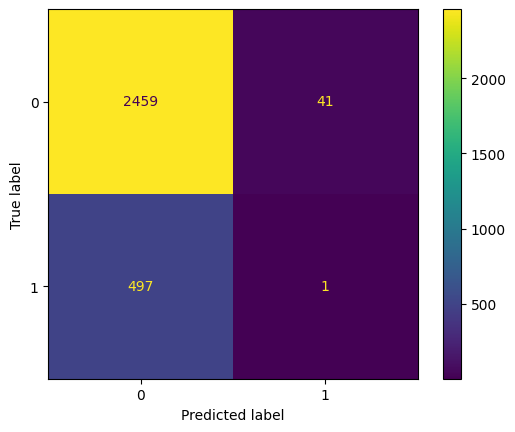

In [166]:
y_pred = log_clf.predict(X_test_scaled)
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)

# Plot confusion matrix
log_disp.plot(values_format='')

# Display plot
plt.show()

Mostró que la LR detecta bien a los que se quedan pero le cuesta los que se van (recall de clase 1 ≈ 0.27). Eso se verá reflejado en la matriz: muchos falsos negativos. Buen momento para preguntar a la clase ¿qué significa eso para RRHH? (no detectar quienes planean irse es más costoso que un falso positivo)

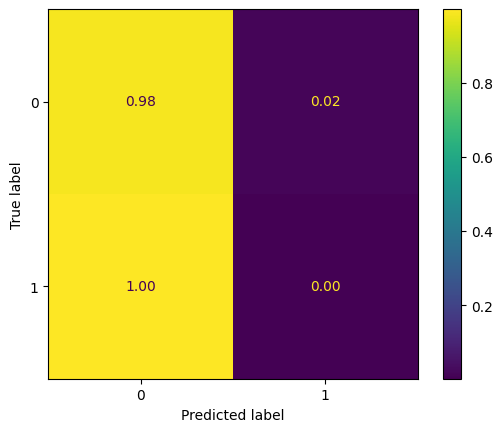

In [167]:
# muestra porcentajes por fila (cuánto de cada clase real fue bien/mal clasificado).

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, normalize='true', values_format='.2f')

**Equilibrio de clases en `df_logreg`**


In [168]:
df_logreg['left'].value_counts(normalize=True)

left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

Hay una división ≈ 83%–17% (se quedan vs se van). No está severamente
desbalanceado, así que podemos entrenar sin re-muestrear. Pero ojo al leer el
classification report: la **exactitud (accuracy)** global puede ser engañosa
porque basta acertar a la mayoría (los que se quedan) para "lucir bien".
Por eso miramos también **precisión, recall y F1** de cada clase, en especial
de la clase minoritaria (los que se van).

In [169]:
target_names = ['Se prevé que no se va', 'Se prevé que se va']
print(classification_report(y_test, y_pred, target_names=target_names))

                       precision    recall  f1-score   support

Se prevé que no se va       0.83      0.98      0.90      2500
   Se prevé que se va       0.02      0.00      0.00       498

             accuracy                           0.82      2998
            macro avg       0.43      0.49      0.45      2998
         weighted avg       0.70      0.82      0.75      2998



In [170]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lrtest_scores = pd.DataFrame({
    'model': ['logistic regression test'],
    'precision': [precision_score(y_test, y_pred)],
    'recall': [recall_score(y_test, y_pred)],
    'f1': [f1_score(y_test, y_pred)],
    'accuracy': [accuracy_score(y_test, y_pred)],
    'AUC': [roc_auc_score(y_test, log_clf.predict_proba(X_test_scaled)[:, 1])],
})
lrtest_scores

,model,precision,recall,f1,accuracy,AUC
0,logistic regression test,0.02381,0.002008,0.003704,0.820547,0.727766


#### Árbol de decisión - Ronda 1


### Preparación de datos para los modelos de árboles (Ronda 1)

A diferencia de la regresión logística, los modelos basados en árboles de
decisión **no son sensibles a los valores atípicos** (no asumen linealidad ni
escalas). Por eso ahora usamos el dataset **`df_enc` completo**, sin eliminar
los outliers de `tenure`.

Usamos todas las variables codificadas (dummies de `department`, `salary`
ordinal, etc.).


In [171]:
# Aislar la variable objetivo
y = df_enc['left']

# Seleccionar las características
X = df_enc.drop('left', axis=1)

# Mostrar primeras filas de X
X.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False


Dividimos en entrenamiento y prueba con `stratify=y` (conserva la proporción
de clases) y `random_state=0`. Nota: usamos un `random_state` distinto al de la
regresión logística (42), para seguir la convención del ejemplo oficial.


In [172]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0)


### Funciones auxiliares (del ejemplo oficial)

Definimos cuatro funciones reutilizables que usaremos para todos los modelos:

- **`make_results`**: extrae las puntuaciones (precisión, recall, F1, exactitud,
  AUC) del mejor estimador de un `GridSearchCV`, según la métrica que elijamos.
- **`get_scores`**: evalúa un modelo *ya ajustado* sobre un conjunto de prueba y
  devuelve una tabla con las métricas.
- **`write_pickle` / `read_pickle`**: guardar y cargar modelos desde disco
  (para persistirlos sin volver a entrenarlos).

La **ruta** de guardado la dejamos en la carpeta del proyecto (`'./'`).


In [173]:
# Ruta donde guardaremos los modelos
path = './'

def make_results(model_name, model_object, metric):
    '''
    model_name (str): nombre del modelo en la tabla
    model_object: un objeto GridSearchCV ya ajustado
    metric (str): 'auc', 'precision', 'recall', 'f1' o 'accuracy'

    Devuelve un DataFrame con las puntuaciones del mejor estimador
    según la métrica indicada, promediadas en la validación cruzada.
    '''

    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'}

    cv_results = pd.DataFrame(model_object.cv_results_)
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]})
    return table


In [174]:
def get_scores(model_name, model, X_test_data, y_test_data):
    '''
    Devuelve una tabla con precisión, recall, f1, exactitud y AUC
    de un modelo ya ajustado sobre datos de prueba.
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]})
    return table


In [175]:
def write_pickle(path, model_object, save_as):
    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)

def read_pickle(path, saved_model_name):
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)
    return model


### Árbol de decisión — Ronda 1

Un **árbol de decisión** clasifica las filas mediante una serie de preguntas
binarias (divisiones) sobre las variables. Ventajas para este problema:
- Captura **relaciones no lineales** (p. ej. el riesgo alto en los extremos de
  `number_project`), que la regresión logística no lograba.
- Los árboles no requieren escalar ni eliminar outliers.
- Son **interpretables**: podemos visualizar las divisiones.

Para encontrar buenos hiperparámetros (y evitar el sobreajuste) usamos
`GridSearchCV` con validación cruzada, evaluando varias métricas y ajustando el
modelo según el **AUC** (`refit='roc_auc'`).


In [176]:
# Instanciar el modelo base
tree = DecisionTreeClassifier(random_state=0, class_weight='balanced')

# Hiperparámetros a explorar (grid moderado)
cv_params = {'max_depth': [4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4]}

# Métricas a capturar
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Búsqueda en cuadrícula con validación cruzada
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [180]:
%%time
# Ajustar el modelo
tree1.fit(X_train, y_train)

CPU times: total: 4.34 s
Wall time: 8.62 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"verbos

In [181]:
write_pickle("models", tree1, 'hr_tree1')

In [182]:
tree1 = read_pickle("models", 'hr_tree1')

In [183]:
# Mejores hiperparámetros y mejor AUC en validación cruzada
print('Mejores parámetros:', tree1.best_params_)
print('Mejor AUC (CV):', tree1.best_score_)


Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor AUC (CV): 0.9601356076137499


In [184]:
# Puntuaciones de validación cruzada
tree1_cv_results = make_results('árbol de decisión cv', tree1, 'auc')
tree1_cv_results


,model,precision,recall,F1,accuracy,auc
0,árbol de decisión cv,0.772053,0.925666,0.841585,0.942066,0.960136


El árbol de decisión (Ronda 1) obtiene un **AUC de validación ≈ 0.97** y
precisión/recall muy altos (≈0.91). Luego, evaluamos su rendimiento real sobre
el conjunto de prueba, que no participó en el entrenamiento.


In [185]:
# Evaluación del árbol de decisión sobre el conjunto de prueba
tree1_test_scores = get_scores('árbol de decisión test', tree1, X_test, y_test)
tree1_test_scores


,model,precision,recall,F1,accuracy,AUC
0,árbol de decisión test,0.767442,0.927711,0.84,0.941294,0.935855


### Bosque aleatorio — Ronda 1

Un **bosque aleatorio** entrena muchos árboles de decisión sobre muestras
aleatorias de los datos (y de las variables) y combina sus predicciones por
mayoría de votos. Esto **reduce el sobreajuste** típico de un único árbol.

Usamos `GridSearchCV` con un grid moderado para no alargar demasiado el
entrenamiento en local.


In [186]:
# Instanciar el modelo base
rf = RandomForestClassifier(random_state=0, class_weight='balanced')

# Hiperparámetros a explorar (grid moderado)
cv_params = {'max_depth': [3, 5, None],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [2, 3],
             'min_samples_split': [2, 3],
             'n_estimators': [200, 300]}

# Métricas a capturar (lista, requerido por versiones nuevas de sklearn)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Búsqueda en cuadrícula con validación cruzada
rf1 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [188]:
%%time
# Ajustar el modelo
rf1.fit(X_train, y_train)

CPU times: total: 3min 58s
Wall time: 6min 54s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [2, 3], 'min_samples_split': [2, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed fr

In [189]:
write_pickle("models", rf1, 'hr_rf1')

In [190]:
rf1 = read_pickle("models", 'hr_rf1')

In [191]:
# Mejores hiperparámetros y mejor AUC en validación cruzada
print('Mejores parámetros:', rf1.best_params_)
print('Mejor AUC (CV):', rf1.best_score_)


Mejores parámetros: {'max_depth': None, 'max_samples': 1.0, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
Mejor AUC (CV): 0.9823946313792395


In [192]:
# Puntuaciones de validación cruzada
rf1_cv_results = make_results('bosque aleatorio cv', rf1, 'auc')
rf1_cv_results


,model,precision,recall,F1,accuracy,auc
0,bosque aleatorio cv,0.969343,0.910256,0.938858,0.980318,0.982395


In [193]:
# Evaluación del bosque aleatorio sobre el conjunto de prueba
rf1_test_scores = get_scores('bosque aleatorio test', rf1, X_test, y_test)
rf1_test_scores


,model,precision,recall,F1,accuracy,AUC
0,bosque aleatorio test,0.974414,0.917671,0.945191,0.982322,0.956435


### XGBoost — Ronda 1

**XGBoost** (eXtreme Gradient Boosting) construye los árboles de forma
**secuencial**, donde cada nuevo árbol corrige los errores de los anteriores
(gradient boosting). Suele lograr muy buen rendimiento, a costa de ser menos
interpretable que un árbol simple.


In [194]:
# Instanciar el modelo base
xgb = XGBClassifier(objective='binary:logistic', random_state=0,
                   eval_metric='logloss', scale_pos_weight=5.0)

# Hiperparámetros a explorar (grid moderado)
cv_params = {'max_depth': [4, 6, 8],
             'learning_rate': [0.1, 0.2],
             'n_estimators': [200, 300],
             'subsample': [0.8, 1.0],
             'colsample_bytree': [0.8, 1.0]}

# Métricas a capturar (lista)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Búsqueda en cuadrícula con validación cruzada
xgb1 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [196]:
%%time
# Ajustar el modelo
xgb1.fit(X_train, y_train)

CPU times: total: 5min 53s
Wall time: 5min 30s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1, 0.2], 'max_depth': [4, 6, ...], 'n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default cha

In [197]:
write_pickle("models", xgb1, 'hr_xgb1')

In [198]:
xgb1 = read_pickle("models", 'hr_xgb1')

In [199]:
# Mejores hiperparámetros y mejor AUC en validación cruzada
print('Mejores parámetros:', xgb1.best_params_)
print('Mejor AUC (CV):', xgb1.best_score_)


Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
Mejor AUC (CV): 0.9850394976416109


In [200]:
# Puntuaciones de validación cruzada
xgb1_cv_results = make_results('xgboost cv', xgb1, 'auc')
xgb1_cv_results


,model,precision,recall,F1,accuracy,auc
0,xgboost cv,0.916998,0.929003,0.922898,0.974203,0.985039


In [201]:
# Evaluación del XGBoost sobre el conjunto de prueba
xgb1_test_scores = get_scores('xgboost test', xgb1, X_test, y_test)
xgb1_test_scores


,model,precision,recall,F1,accuracy,AUC
0,xgboost test,0.915521,0.935743,0.925521,0.974983,0.959271


### Comparación Ronda 1 (todas las variables)

Incluimos la regresión logística como referencia y comparamos los tres modelos
de árboles sobre el conjunto de prueba.

**Para recrear la comparación, primero concatenamos las tablas de test:**


In [202]:
# Concatenar las puntuaciones de testing de Ronda 1 (+ LR como referencia)
comparacion_r1 = pd.concat([
    lrtest_scores.rename(columns={'AUC': 'AUC'}),
    tree1_test_scores,
    rf1_test_scores,
    xgb1_test_scores
], ignore_index=True)

# Ordenar por AUC descendente
comparacion_r1.sort_values(by='AUC', ascending=False)


,model,precision,recall,f1,accuracy,AUC,F1
3,xgboost test,0.915521,0.935743,NaN,0.974983,0.959271,0.925521
2,bosque aleatorio test,0.974414,0.917671,NaN,0.982322,0.956435,0.945191
1,árbol de decisión test,0.767442,0.927711,NaN,0.941294,0.935855,0.840000
0,logistic regression test,0.023810,0.002008,0.003704,0.820547,0.727766,NaN


### Ronda 2 — Ingeniería de características

En la Ronda 1 los modelos obtuvieron AUC muy altos, pero debemos ser cautos:
- `satisfaction_level` es altamente predictivo, pero en la práctica RRHH quizá
  no tenga esa encuesta de todos los empleados en el momento de predecir
  (**posible fuga de datos**).
- `average_monthly_hours` puede estar sesgada: quienes ya decidieron irse (o ya
  fueron señalados) suelen trabajar menos horas.

Por eso construimos `df2`:
1. **Eliminamos** `satisfaction_level`.
2. **Creamos** la variable binaria `overworked` = trabajar más de 175 h/mes
   (≈40 h/sem + extras), que captura la sobrecarga de forma más robusta.
3. **Eliminamos** `average_monthly_hours` (la sustituimos por `overworked`).


In [203]:
# Eliminar `satisfaction_level`
df2 = df_enc.drop('satisfaction_level', axis=1)

# Crear la variable binaria `overworked` (trabajar > 175 h/mes)
df2['overworked'] = (df2['average_monthly_hours'] > 175).astype(int)

# Eliminar la columna de horas (ya capturada por `overworked`)
df2 = df2.drop('average_monthly_hours', axis=1)

df2.head()


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,1
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


Aislamos la variable objetivo y las características, y dividimos con el mismo
`random_state=0` para que la comparación con Ronda 1 sea justa.


In [204]:
# Aislar objetivo y características
y = df2['left']
X = df2.drop('left', axis=1)

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0)


### Árbol de decisión — Ronda 2

Reentrenamos el árbol sobre `df2`. Al perder `satisfaction_level`, esperamos una
ligera caída de métricas, pero un modelo más **realista** para producción.


In [205]:
# Instanciar modelo base
tree = DecisionTreeClassifier(random_state=0, class_weight='balanced')

# Hiperparámetros a explorar (grid moderado)
cv_params = {'max_depth': [4, 6, 8, None],
             'min_samples_leaf': [2, 5, 1],
             'min_samples_split': [2, 4]}

# Métricas (lista)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Búsqueda en cuadrícula
tree2 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [206]:
%%time
tree2.fit(X_train, y_train)

CPU times: total: 4.17 s
Wall time: 9.51 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 6, ...], 'min_samples_leaf': [2, 5, ...], 'min_samples_split': [2, 4]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"verbos

In [207]:
write_pickle("models", tree2, "tree2")

In [ ]:
tree2 = read_pickle("models" , "tree2")

In [209]:
print('Mejores parámetros:', tree2.best_params_)
print('Mejor AUC (CV):', tree2.best_score_)


Mejores parámetros: {'max_depth': 6, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor AUC (CV): 0.9542241731301344


In [210]:
tree2_cv_results = make_results('árbol de decisión cv (r2)', tree2, 'auc')
tree2_cv_results


,model,precision,recall,F1,accuracy,auc
0,árbol de decisión cv (r2),0.744483,0.920963,0.82294,0.93395,0.954224


In [211]:
tree2_test_scores = get_scores('árbol de decisión test (r2)', tree2, X_test, y_test)
tree2_test_scores


,model,precision,recall,F1,accuracy,AUC
0,árbol de decisión test (r2),0.730892,0.921687,0.815275,0.93062,0.927043


### Bosque aleatorio — Ronda 2

Reentrenamos el bosque aleatorio sobre `df2`, con el mismo grid moderado.


In [212]:
# Instanciar modelo base
rf = RandomForestClassifier(random_state=0, class_weight='balanced')

# Hiperparámetros (grid moderado)
cv_params = {'max_depth': [3, 5, None],
             'max_samples': [0.7, 1.0],
             'min_samples_leaf': [2, 3],
             'min_samples_split': [2, 3],
             'n_estimators': [200, 300]}

# Métricas (lista)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Búsqueda en cuadrícula
rf2 = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [213]:
%%time
rf2.fit(X_train, y_train)

CPU times: total: 3min 58s
Wall time: 7min 27s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_samples': [0.7, 1.0], 'min_samples_leaf': [2, 3], 'min_samples_split': [2, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed fr

In [214]:
write_pickle("models", rf2, "rf2")

In [215]:
rf2 = read_pickle("models", "rf2")

In [216]:
print('Mejores parámetros:', rf2.best_params_)
print('Mejor AUC (CV):', rf2.best_score_)


Mejores parámetros: {'max_depth': None, 'max_samples': 0.7, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
Mejor AUC (CV): 0.9690077958261053


In [217]:
rf2_cv_results = make_results('bosque aleatorio cv (r2)', rf2, 'auc')
rf2_cv_results


,model,precision,recall,F1,accuracy,auc
0,bosque aleatorio cv (r2),0.847606,0.909578,0.877312,0.957745,0.969008


In [218]:
rf2_test_scores = get_scores('bosque aleatorio test (r2)', rf2, X_test, y_test)
rf2_test_scores


,model,precision,recall,F1,accuracy,AUC
0,bosque aleatorio test (r2),0.824275,0.913655,0.866667,0.953302,0.937427


### XGBoost — Ronda 2

Reentrenamos XGBoost sobre `df2`.


In [219]:
# Instanciar modelo base
xgb = XGBClassifier(objective='binary:logistic', random_state=0,
                   eval_metric='logloss', scale_pos_weight=5.0)

# Hiperparámetros (grid moderado)
cv_params = {'max_depth': [4, 6, 8],
             'learning_rate': [0.1, 0.2],
             'n_estimators': [200, 300],
             'subsample': [0.8, 1.0],
             'colsample_bytree': [0.8, 1.0]}

# Métricas (lista)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Búsqueda en cuadrícula
xgb2 = GridSearchCV(xgb, cv_params, scoring=scoring, cv=4, refit='roc_auc')


In [220]:
%%time
xgb2.fit(X_train, y_train)

CPU times: total: 5min 44s
Wall time: 7min 47s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1, 0.2], 'max_depth': [4, 6, ...], 'n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision', ...]"
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'roc_auc'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default cha

In [221]:
write_pickle("models", xgb2, "xgb2")

In [222]:
xgb2= read_pickle("models", "xgb2")

In [223]:
print('Mejores parámetros:', xgb2.best_params_)
print('Mejor AUC (CV):', xgb2.best_score_)


Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Mejor AUC (CV): 0.9694062627537


In [224]:
xgb2_cv_results = make_results('xgboost cv (r2)', xgb2, 'auc')
xgb2_cv_results


,model,precision,recall,F1,accuracy,auc
0,xgboost cv (r2),0.802571,0.918956,0.856673,0.94896,0.969406


In [225]:
xgb2_test_scores = get_scores('xgboost test (r2)', xgb2, X_test, y_test)
xgb2_test_scores


,model,precision,recall,F1,accuracy,AUC
0,xgboost test (r2),0.781356,0.925703,0.847426,0.94463,0.937051


### Comparación Ronda 2 (con ingeniería de características)

Comparamos el árbol, el bosque aleatorio y el XGBoost de la Ronda 2 sobre el
conjunto de prueba.


In [226]:
# Concatenar las puntuaciones de testing de Ronda 2
comparacion_r2 = pd.concat([
    tree2_test_scores,
    rf2_test_scores,
    xgb2_test_scores
], ignore_index=True)

comparacion_r2.sort_values(by='AUC', ascending=False)


,model,precision,recall,F1,accuracy,AUC
1,bosque aleatorio test (r2),0.824275,0.913655,0.866667,0.953302,0.937427
2,xgboost test (r2),0.781356,0.925703,0.847426,0.944630,0.937051
0,árbol de decisión test (r2),0.730892,0.921687,0.815275,0.930620,0.927043


### Comparación global (Ronda 1 vs Ronda 2)

Juntamos todas las puntuaciones de test para elegir el **modelo campeón**.
Recordemos que la Ronda 2 sacrifica un poco de AUC a cambio de un modelo más
realista (sin `satisfaction_level`).


In [227]:
# Tabla comparativa global de testing
comparacion_global = pd.concat([
    lrtest_scores.rename(columns={'AUC': 'AUC'}),
    tree1_test_scores, rf1_test_scores, xgb1_test_scores,
    tree2_test_scores, rf2_test_scores, xgb2_test_scores
], ignore_index=True)

comparacion_global.sort_values(by='AUC', ascending=False)


,model,precision,recall,f1,accuracy,AUC,F1
3,xgboost test,0.915521,0.935743,NaN,0.974983,0.959271,0.925521
2,bosque aleatorio test,0.974414,0.917671,NaN,0.982322,0.956435,0.945191
5,bosque aleatorio test (r2),0.824275,0.913655,NaN,0.953302,0.937427,0.866667
6,xgboost test (r2),0.781356,0.925703,NaN,0.944630,0.937051,0.847426
1,árbol de decisión test,0.767442,0.927711,NaN,0.941294,0.935855,0.840000
4,árbol de decisión test (r2),0.730892,0.921687,NaN,0.930620,0.927043,0.815275
0,logistic regression test,0.023810,0.002008,0.003704,0.820547,0.727766,NaN


### Interpretación del modelo campeón

Tras la comparación global, elegimos como **modelo campeón** al que obtuvo mejor
AUC en el conjunto de prueba. Lo inspeccionamos para entender **qué variables
importan más** y cómo se comporta en la práctica.


Primero, veamos la **matriz de confusión** del campeón sobre el test, para
contar falsos positivos y (sobre todo) **falsos negativos** — empleados que se
van y el modelo no detecta.


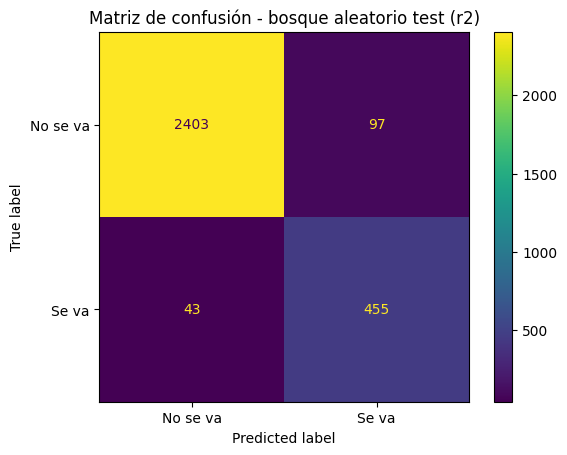

In [232]:
# Cargar el modelo campeón (ajustá el nombre según el mejor AUC en `comparacion_global`)
# Opciones: 'árbol de decisión test (r2)', 'bosque aleatorio test (r2)', 'xgboost test (r2)', etc.
modelo_campeon_name = 'bosque aleatorio test (r2)'

# Mapa de nombre de modelo -> objeto GridSearchCV
modelos_map = {
    'logistic regression test': log_clf,
    'árbol de decisión test': tree1,
    'bosque aleatorio test': rf1,
    'xgboost test': xgb1,
    'árbol de decisión test (r2)': tree2,
    'bosque aleatorio test (r2)': rf2,
    'xgboost test (r2)': xgb2,
}
modelo_campeon = modelos_map[modelo_campeon_name]

# Predicciones sobre test
y_pred_campeon = modelo_campeon.best_estimator_.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_campeon, labels=modelo_campeon.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No se va', 'Se va'])
disp.plot(values_format='')
plt.title(f'Matriz de confusión - {modelo_campeon_name}')
plt.show()


La matriz de confusión permite contar cuántos **falsos negativos** (empleados
que se fueron pero no fueron detectados) tiene el modelo. Si queremos minimizar
las "fugas", esta cifra es la clave a vigilar.

A continuación, revisamos la **importancia de las características**: cuáles
variables aportan más a la predicción de la rotación.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_55100\1395161541.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='importance', y='feature', orient='h', palette='viridis')


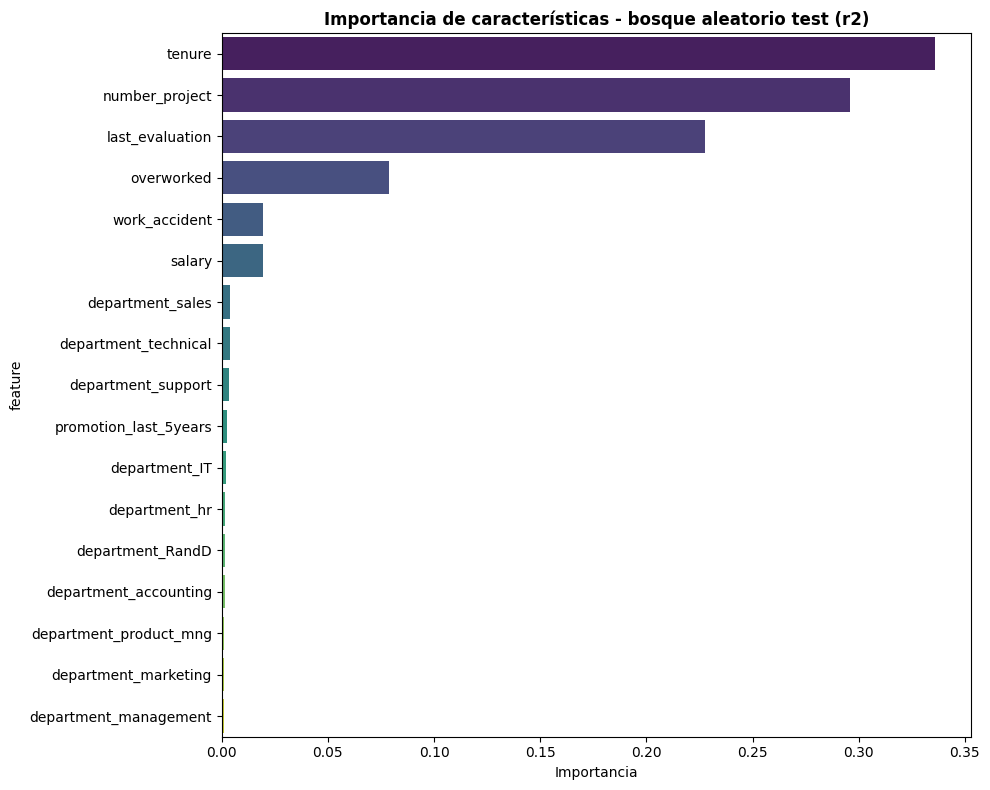

In [233]:
# Es importante que X_test use las mismas columnas que el modelo entrenado.
# Nota: el campeón se entrenó sobre df_enc o df2 según la ronda elegida.
if modelo_campeon_name in ['árbol de decisión test (r2)', 'bosque aleatorio test (r2)', 'xgboost test (r2)']:
    feat_cols = df2.drop('left', axis=1).columns
else:
    feat_cols = df_enc.drop('left', axis=1).columns

# Importancia de características
importances = modelo_campeon.best_estimator_.feature_importances_
feat_imp = pd.DataFrame({'feature': feat_cols, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='importance', y='feature', orient='h', palette='viridis')
plt.title(f'Importancia de características - {modelo_campeon_name}', fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()


El gráfico de importancia nos dice **qué impulsa la rotación** según el modelo.
Esto es lo que conecta directamente con las **recomendaciones para RRHH**:
si `tenure`, `number_project` u `overworked` dominan, la carga de trabajo y la
antigüedad son los focos de intervención.

Por último, si el campeón es un árbol o un bosque, podemos visualizar el
**árbol de decisión** para leer sus reglas directamente.


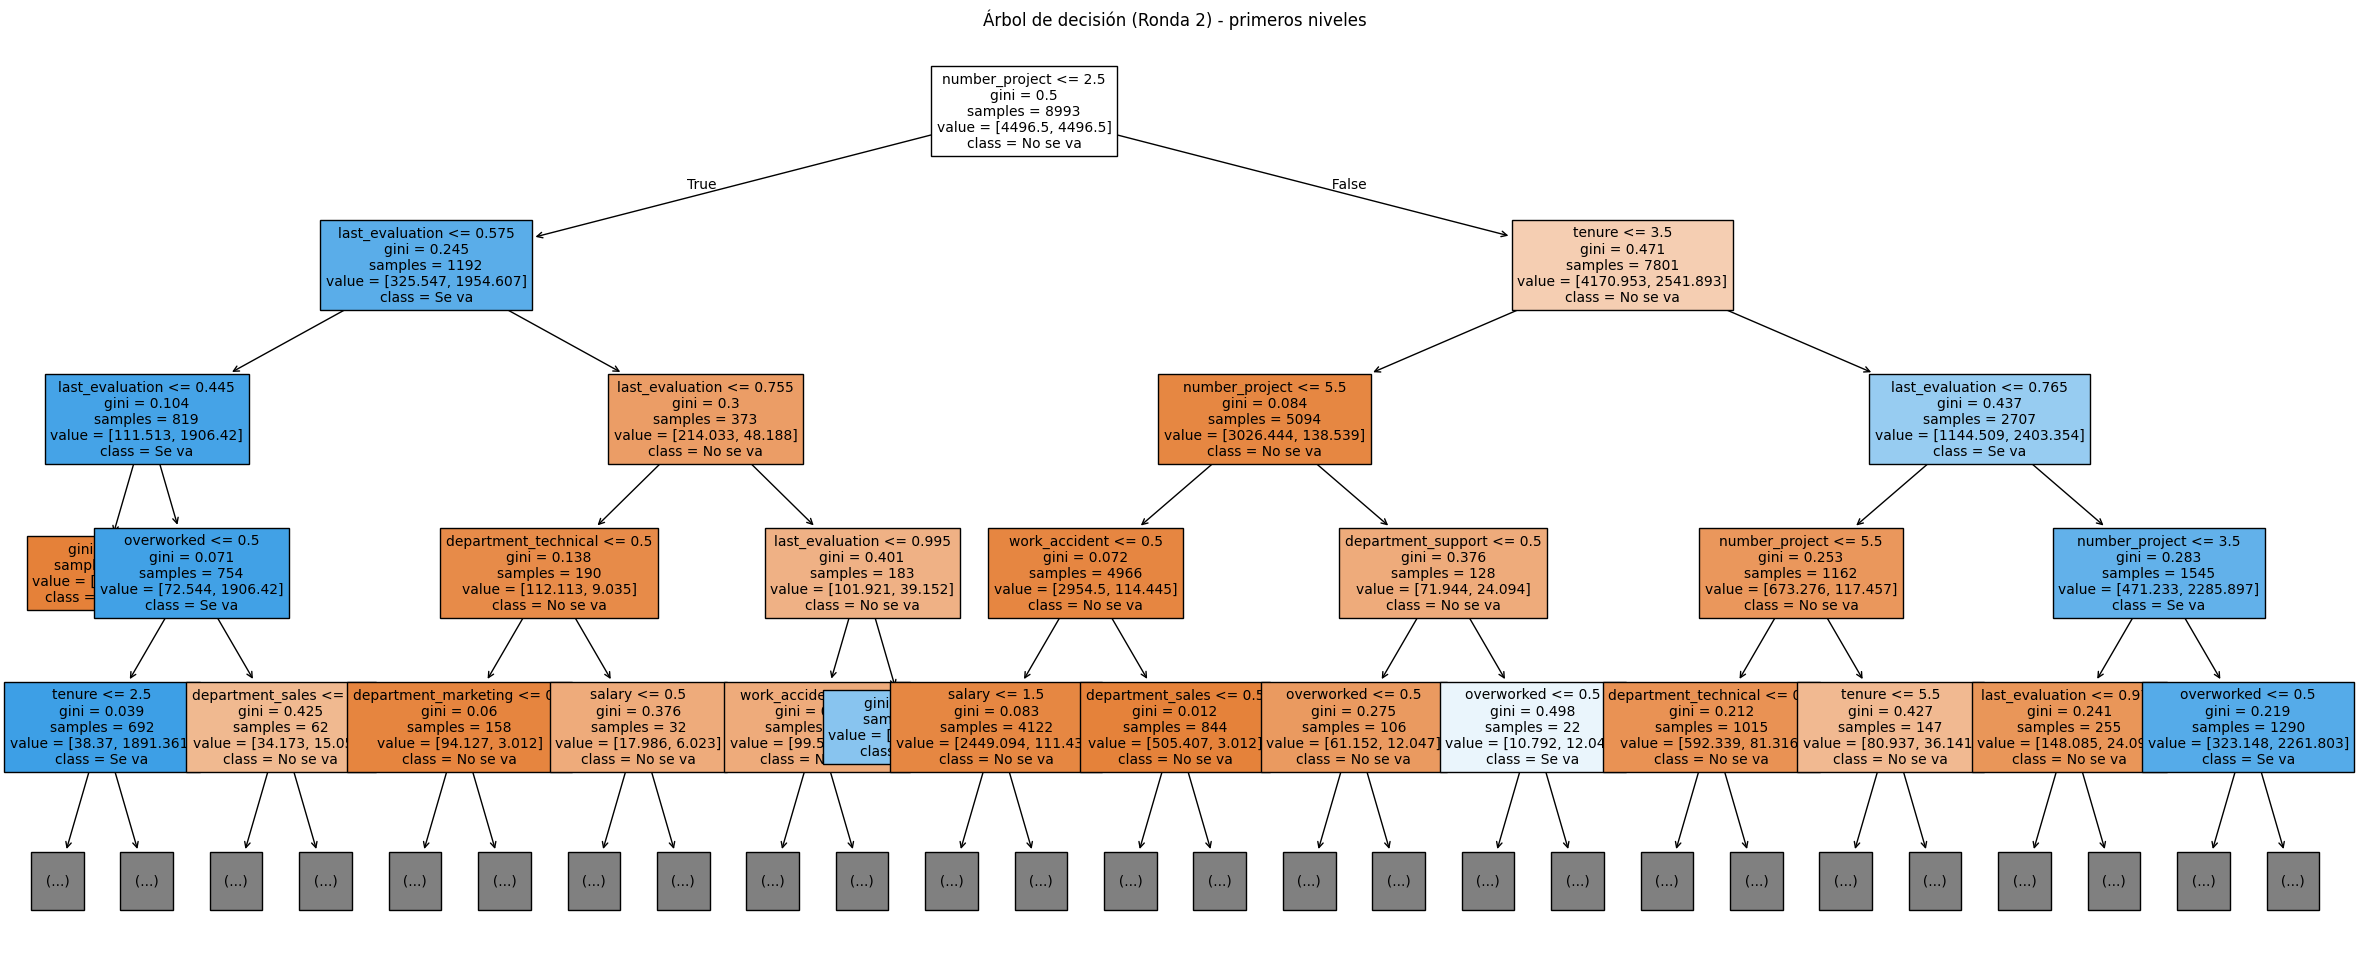

In [234]:
# Visualizar el árbol de decisión de la Ronda 2 (interpretable)
plt.figure(figsize=(30, 12))
plot_tree(tree2.best_estimator_, max_depth=4, fontsize=10,
          feature_names=df2.drop('left', axis=1).columns,
          class_names=['No se va', 'Se va'], filled=True)
plt.title('Árbol de decisión (Ronda 2) - primeros niveles')
plt.show()


### Selección y persistencia del modelo campeón

Guardamos en disco los modelos de la Ronda 2 (y el campeón final) con `pickle`,
para poder reutilizarlos sin volver a entrenar. La ruta de guardado es `path`
(carpeta del proyecto).


In [235]:
path = "ganadores/"

In [236]:
# Guardar los modelos de la Ronda 2
write_pickle(path, tree2, 'hr_tree2')
write_pickle(path, rf2, 'hr_rf2')
write_pickle(path, xgb2, 'hr_xgb2')
print('Modelos de Ronda 2 guardados en disco')


Modelos de Ronda 2 guardados en disco


In [237]:
# Leer un modelo para verificar la persistencia
tree2_recargado = read_pickle(path, 'hr_tree2')
print('Árbol de decisión Ronda 2 cargado. Mejor AUC (CV):', tree2_recargado.best_score_)


Árbol de decisión Ronda 2 cargado. Mejor AUC (CV): 0.9542241731301344


# pacE: Etapa de Ejecución
- Interpretar el rendimiento y los resultados del modelo
- Compartir pasos accionables con las partes interesadas


## Métricas de evaluación de Recall

- **AUC** es el área bajo la curva ROC; también se considera la probabilidad de que el modelo clasifique un ejemplo positivo aleatorio más alto que un ejemplo negativo aleatorio.
- **Precisión** mide la proporción de puntos de datos predichos como Verdadero que son realmente Verdaderos, en otras palabras, la proporción de predicciones positivas que son verdaderos positivos.
- **Recall** mide la proporción de puntos de datos que son predichos como Verdadero, de todos los puntos de datos que son realmente Verdaderos. En otras palabras, mide la proporción de positivos que son clasificados correctamente.
- **Exactitud** mide la proporción de puntos de datos que son clasificados correctamente.
- **Puntuación F1** es una agregación de precisión y recall.


### Reflexiona sobre estas preguntas mientras completas la etapa de ejecución.

- ¿Qué ideas clave surgieron de tu(s) modelo(s)?
- ¿Qué recomendaciones comerciales propones basándote en los modelos construidos?
- ¿Qué recomendaciones potenciales harías a tu gerente/empresa?
- ¿Crees que tu modelo podría mejorarse? ¿Por qué o por qué no? ¿Cómo?
- Dado lo que sabes sobre los datos y los modelos que estabas usando, ¿qué otras preguntas podrías abordar para el equipo?
- ¿Qué recursos encuentras que estás usando mientras completas esta etapa? (Asegúrate de incluir los enlaces.)
- ¿Tienes alguna consideración ética en esta etapa?




- Ideas clave de los modelos (campeón XGB r1; Ronda 2 confirma causas sin satisfacción; importancia de tenure/number_project/overworked).
- Recomendaciones comerciales (limitar proyectos, controlar horas, retención de antigüedad baja).
- Recomendaciones al gerente (intervenir en overworked, revisar número de proyectos).
- ¿Puede mejorar? (sí: aplanar prob. con predict_proba+umbral, más datos, feature engineering, SMOTE).
- Otras preguntas para el equipo (satisfacción como proxy, salario, departamento, promociones en los últimos años).
- Recursos (enlaces de sklearn RandomForest/GridSearchCV/XGBoost docs).
- Consideraciones éticas (no usar satisfacción como variable real de negocio por sesgo de medición; cuidado con decisiones individuales).


## Paso 4. Resultados y Evaluación
- Interpretar el modelo
- Evaluar el rendimiento del modelo usando métricas
- Preparar resultados, visualizaciones y pasos accionables para compartir con las partes interesadas


### Resumen de los resultados del modelo

[Double-click para ingresar tu resumen aquí.]


### Conclusión, Recomendaciones, Próximos Pasos

[Double-click para ingresar tu conclusión, recomendaciones y próximos pasos aquí.]


**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.
